# Salary Data Analysis & Predictive Modelling

**Objective:** End-to-end analysis of an employee compensation dataset — from raw data exploration and cleaning, through feature engineering, to predictive modelling (linear regression, logistic regression) and unsupervised learning (PCA, factor analysis, hierarchical clustering).

**Dataset:** `Salary_MD.csv` — 6,684 employee records, 9 features covering demographics, role, experience, education and salary.

**Outputs:** All charts are saved as `.png` files under `./charts/` for use in reports or presentations.


## 0. Environment Setup

In [1]:
!pip install statsmodels

In [2]:
import subprocess, sys
for pkg in ['statsmodels']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kstest
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.discrete.discrete_model as sm_disc

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.metrics import (mean_squared_error, r2_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')

# Chart output directory
os.makedirs('charts', exist_ok=True)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

def save_fig(name):
    path = f'charts/{name}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  -> saved: {path}')


## 1. Data Loading & First Look

In [4]:
df_raw = pd.read_csv('Salary_MD.csv')
pd.options.display.float_format = '{:.2f}'.format
print(f'Shape: {df_raw.shape}')
df_raw.head(10)


Shape: (6684, 9)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Senior
0,32,Male,1.00,Software Engineer,5.00,90000,UK,White,0
1,28,Female,2.00,Data Analyst,3.00,65000,USA,NaN,0
2,45,Male,3.00,Manager,15.00,150000,Canada,White,1
3,36,Female,1.00,Sales Associate,7.00,60000,USA,Hispanic,0
4,52,Male,2.00,Director,20.00,200000,USA,Asian,0
5,29,Male,1.00,Marketing Analyst,2.00,55000,USA,Hispanic,0
6,42,Female,2.00,Product Manager,12.00,120000,USA,Asian,0
7,31,Male,1.00,Sales Manager,4.00,80000,China,Korean,0
8,26,Female,1.00,Marketing Coordinator,1.00,45000,China,Chinese,0
9,38,Male,3.00,Scientist,10.00,110000,Australia,Australian,1


In [5]:
df_raw.describe()


,Age,Education Level,Years of Experience,Salary,Senior
count,6684.00,6661.00,6684.00,6684.00,6684.00
mean,33.15,1.62,8.16,116433.83,0.14
std,8.62,0.88,7.36,67385.36,0.35
min,0.00,0.00,0.00,0.00,0.00
25%,28.00,1.00,3.00,70000.00,0.00
50%,32.00,1.00,7.00,115000.00,0.00
75%,38.00,2.00,12.00,160000.00,0.00
max,110.00,3.00,200.00,2159320.00,1.00


In [6]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 6684 entries, 0 to 6683
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6684 non-null   int64  
 1   Gender               6613 non-null   str    
 2   Education Level      6661 non-null   float64
 3   Job Title            6644 non-null   str    
 4   Years of Experience  6684 non-null   float64
 5   Salary               6684 non-null   int64  
 6   Country              6660 non-null   str    
 7   Race                 6521 non-null   str    
 8   Senior               6684 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 470.1 KB


## 2. Univariate Analysis of Key Variables

### 2.1 Salary


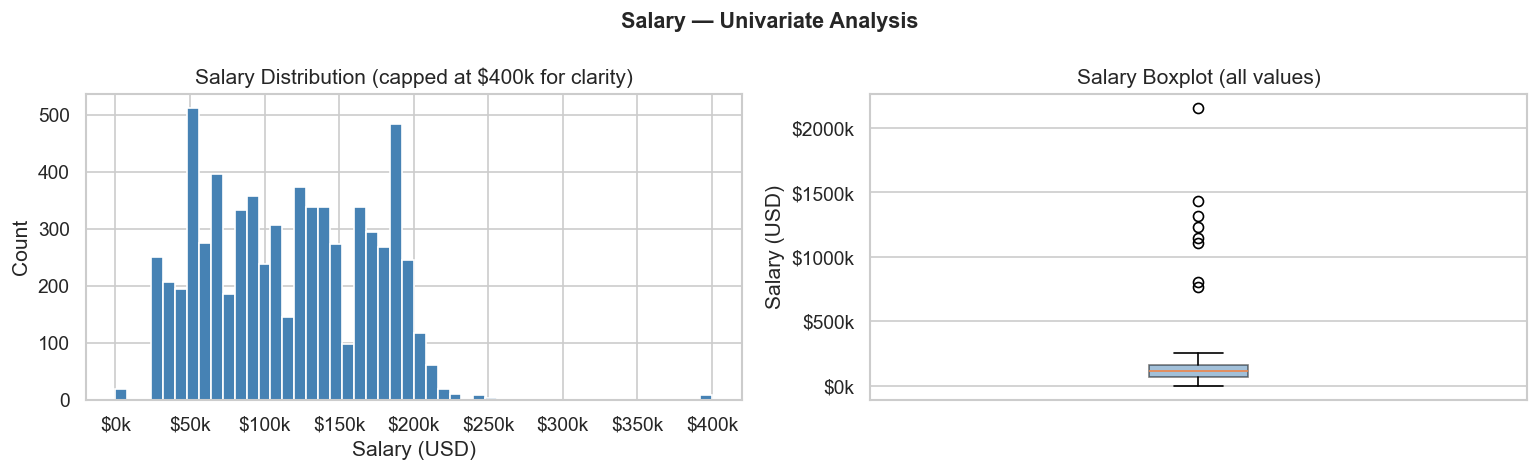

  -> saved: charts/01_salary_univariate.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram — axis capped to exclude extreme outliers for visual clarity
axes[0].hist(df_raw['Salary'].clip(upper=400_000), bins=50,
             color='steelblue', edgecolor='white')
axes[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[0].set_title('Salary Distribution (capped at $400k for clarity)')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')

# Boxplot — all values
axes[1].boxplot(df_raw['Salary'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].set_title('Salary Boxplot (all values)')
axes[1].set_ylabel('Salary (USD)')
axes[1].set_xticks([])

plt.suptitle('Salary — Univariate Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('01_salary_univariate')


In [8]:
sal = df_raw['Salary']
print('── Salary Statistics ──────────────────────────────────────────────────')
print(f'  Count    : {sal.count():,}     | Nulls         : {sal.isnull().sum()}')
print(f'  Mean     : ${sal.mean():,.0f}  | Median        : ${sal.median():,.0f}')
print(f'  Std Dev  : ${sal.std():,.0f}  | Coeff.Var     : {sal.std()/sal.mean():.2%}')
print(f'  Min      : ${sal.min():,.0f}       | Max           : ${sal.max():,.0f}')
print(f'  25th pct : ${sal.quantile(0.25):,.0f}  | 75th pct      : ${sal.quantile(0.75):,.0f}')
print(f'  Skewness : {sal.skew():.2f}           | Kurtosis      : {sal.kurtosis():.2f}')
print(f'  Records with $0 salary   : {(sal == 0).sum()}')
print(f'  Records > $500k          : {(sal > 500_000).sum()}')


── Salary Statistics ──────────────────────────────────────────────────
  Count    : 6,684     | Nulls         : 0
  Mean     : $116,434  | Median        : $115,000
  Std Dev  : $67,385  | Coeff.Var     : 57.87%
  Min      : $0       | Max           : $2,159,320
  25th pct : $70,000  | 75th pct      : $160,000
  Skewness : 8.12           | Kurtosis      : 190.84
  Records with $0 salary   : 15
  Records > $500k          : 8


**Findings — Salary:**

- **6,684 records, zero nulls.** Mean ($116k) and median ($115k) are almost identical, which tells us that despite visible extremes, outliers are few relative to the full dataset. They distort the standard deviation ($67k) but not the central tendency — this is confirmed by skewness of 8.12.
- **Minimum of $0:** 15 records have `Salary = 0`. While technically possible (unpaid internships), this is atypical in a compensation dataset and likely signals data-entry errors. These will be filtered.
- **Maximum of $2.16M:** Physically possible for a C-suite executive but sits far outside the IQR ($70k–$160k). Qualifies as an outlier in this specific dataset.
- The **distribution is roughly rectangular** in the $0–$250k band with a pronounced right tail — not a standard Gaussian. Skewness = 8.12 confirms this.
- **Implication for modelling:** A right-skewed target variable is expected to produce heteroscedastic residuals in OLS. A log-transform of Salary is worth considering; residual diagnostics will confirm this.


### 2.2 Years of Experience

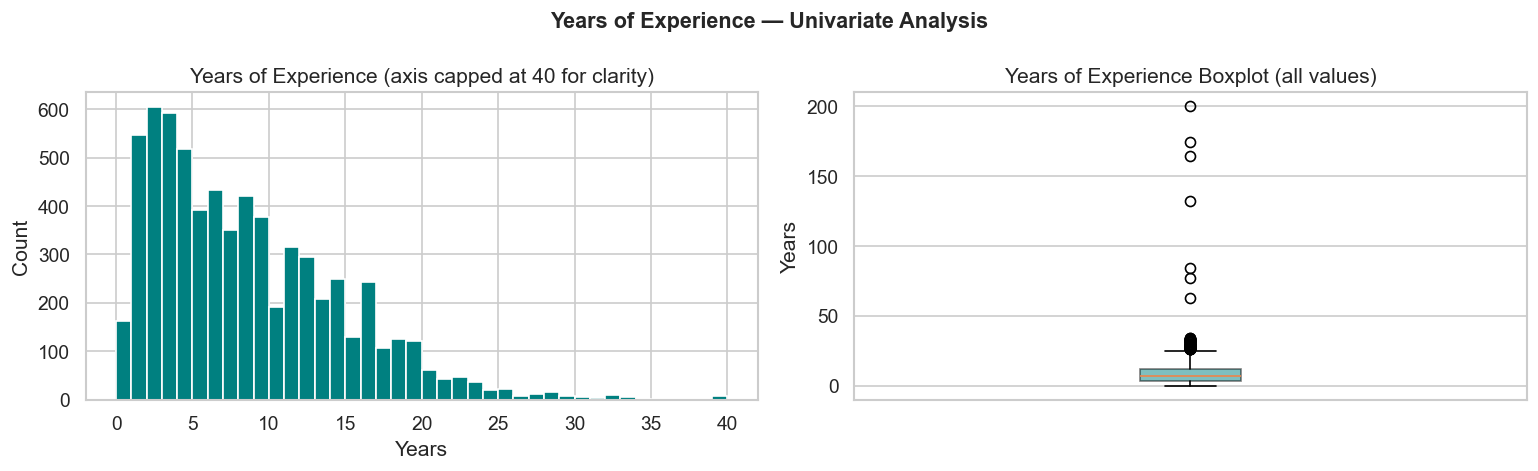

  -> saved: charts/02_yoe_univariate.png


In [9]:
yoe = df_raw['Years of Experience']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(yoe.clip(upper=40), bins=40, color='teal', edgecolor='white')
axes[0].set_title('Years of Experience (axis capped at 40 for clarity)')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Count')

axes[1].boxplot(yoe.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.5))
axes[1].set_title('Years of Experience Boxplot (all values)')
axes[1].set_xticks([])
axes[1].set_ylabel('Years')

plt.suptitle('Years of Experience — Univariate Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('02_yoe_univariate')


In [10]:
print('── Years of Experience Statistics ─────────────────────────────────────')
print(f'  dtype    : {yoe.dtype}   (decimal values present, e.g. 0.5, 1.5)')
print(f'  Count    : {yoe.count():,}     | Nulls    : {yoe.isnull().sum()}')
print(f'  Mean     : {yoe.mean():.1f} yrs   | Median   : {yoe.median():.1f} yrs')
print(f'  Std Dev  : {yoe.std():.1f} yrs   | Skewness : {yoe.skew():.2f}')
print(f'  Min      : {yoe.min():.1f} yrs   | Max      : {yoe.max():.1f} yrs')
print(f'  25th pct : {yoe.quantile(0.25):.1f} yrs   | 75th pct : {yoe.quantile(0.75):.1f} yrs')
print()
n_impossible = (yoe > 60).sum()
n_zero       = (yoe == 0).sum()
print(f'  Records with YoE > 60 yrs (impossible): {n_impossible}')
print(f'  Records with YoE = 0 yrs (entry-level):  {n_zero}')


── Years of Experience Statistics ─────────────────────────────────────
  dtype    : float64   (decimal values present, e.g. 0.5, 1.5)
  Count    : 6,684     | Nulls    : 0
  Mean     : 8.2 yrs   | Median   : 7.0 yrs
  Std Dev  : 7.4 yrs   | Skewness : 7.35
  Min      : 0.0 yrs   | Max      : 200.0 yrs
  25th pct : 3.0 yrs   | 75th pct : 12.0 yrs

  Records with YoE > 60 yrs (impossible): 7
  Records with YoE = 0 yrs (entry-level):  162


**Findings — Years of Experience:**

- **No null values.** The distribution shows a strong **right skew**: the bulk of employees have under 15 years of experience (25th pct = 3 yrs, median = 7 yrs), with a long decreasing tail toward higher tenure.
- **dtype = float64 with decimal values** (0.5, 1.5 …). Fractional years may represent partial-year measurements (e.g. 6 months = 0.5) or data-entry quirks. For modelling purposes the float type is retained; rounding to integer would lose this precision without clear benefit.
- **Max = 200 years is physically impossible.** Records with YoE > 60 will be removed as implausible. Records with 0 years are plausible (entry-level), consistent with the 25th percentile = 3 yrs — these are retained unless other variables indicate inconsistency.
- The **right-skewed shape** means IQR is a better outlier method than Z-score for this variable (detailed in Section 5).


### 2.3 Job Title

In [11]:
jt_counts = df_raw['Job Title'].value_counts(dropna=False)
print(f'Unique Job Titles  : {df_raw["Job Title"].nunique()}')
print(f'Null values        : {df_raw["Job Title"].isnull().sum()}')
print()
print('Top 15 titles by frequency:')
print(jt_counts.head(15).to_string())
print()
rare = jt_counts[jt_counts < 10]
print(f'Titles with < 10 records: {len(rare)} titles covering {rare.sum()} records '
      f'({rare.sum()/len(df_raw):.1%} of dataset)')


Unique Job Titles  : 129
Null values        : 40

Top 15 titles by frequency:
Job Title
Software Engineer            804
Data Scientist               511
Data Analyst                 387
Software Engineer Manager    376
Product Manager              320
Project Engineer             316
Marketing Manager            314
Full Stack Engineer          301
Back end Developer           239
Front end Developer          238
Sales Associate              212
Software Developer           186
Marketing Coordinator        163
Human Resources Manager      152
Marketing Analyst            143

Titles with < 10 records: 84 titles covering 162 records (2.4% of dataset)


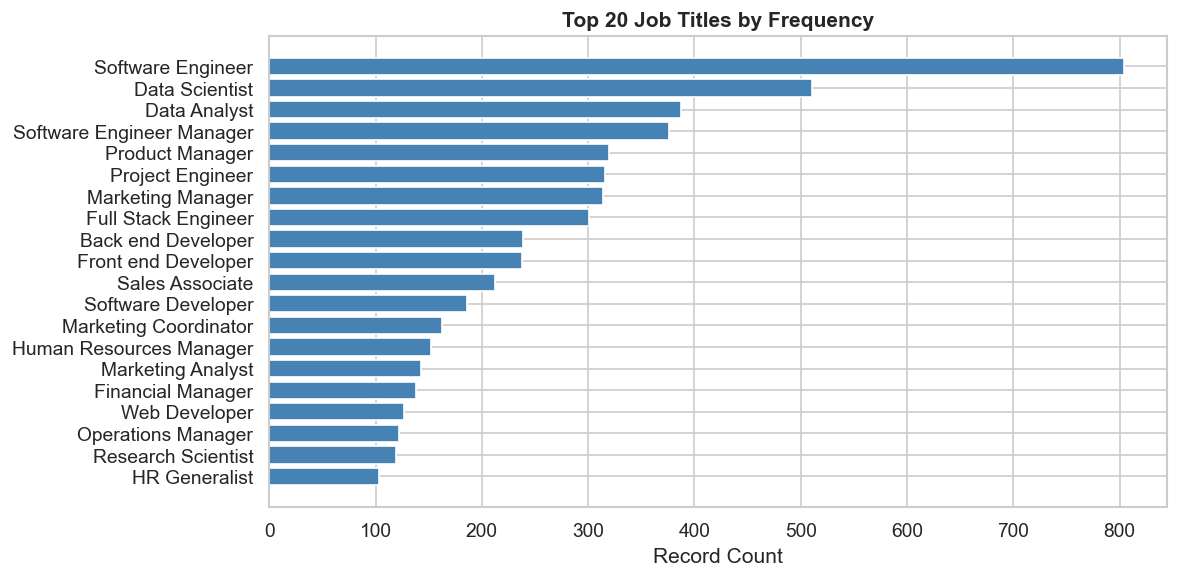

  -> saved: charts/03_job_title_frequency.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
top20 = jt_counts.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Record Count')
ax.set_title('Top 20 Job Titles by Frequency', fontweight='bold')
plt.tight_layout()
save_fig('03_job_title_frequency')


**Findings — Job Title:**

- **129 unique categories** — the most complex variable. Direct one-hot encoding without grouping would generate a very sparse 129-column dummy matrix with many near-empty columns, inflating dimensionality and harming model stability.
- **40 null values** (~0.6% of records). The null pattern will be examined for correlation with other variables (Section 3) before deciding on imputation strategy.
- **Many low-frequency categories**: several titles appear in fewer than 10 records. These contribute negligible signal to any model and will be collapsed into an `"Other"` bucket.
- The dataset is **heavily tech-oriented**: Software Engineer, Data Scientist, Data Analyst, and Product Manager dominate, suggesting a corporate technology sector context. Salary benchmarks should be interpreted within that frame.


## 3. Bivariate & Multivariate Relationships

### 3.1 Numerical Correlations


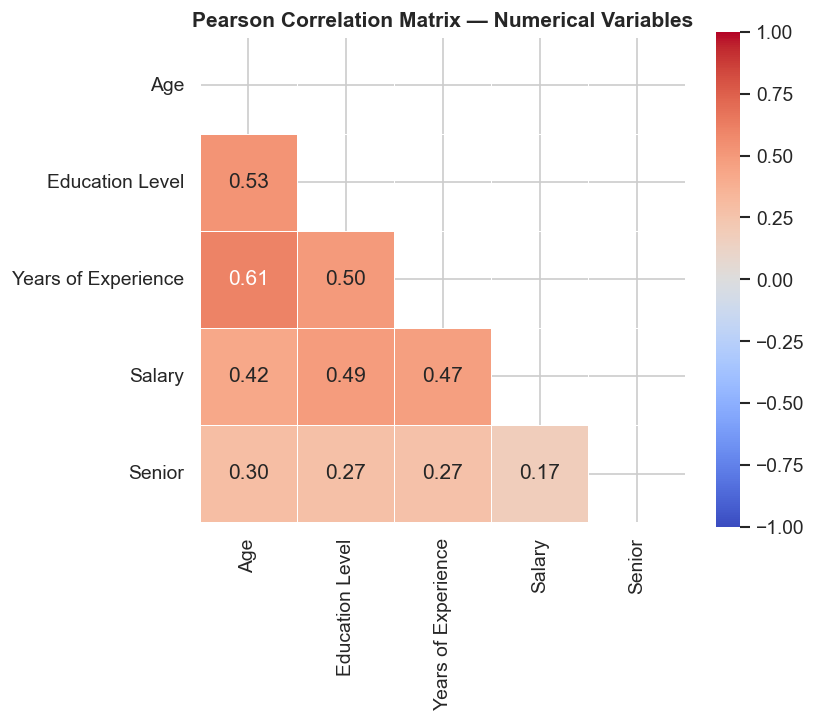

  -> saved: charts/04_correlation_matrix.png


In [13]:
num_cols  = df_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr      = df_raw[num_cols].corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            mask=mask_upper, ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Pearson Correlation Matrix — Numerical Variables', fontweight='bold')
plt.tight_layout()
save_fig('04_correlation_matrix')


In [14]:
# Extract and rank all off-diagonal pairs
corr_pairs = (corr.where(~mask_upper)
               .stack()
               .reset_index()
               .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: 'r'}))
corr_pairs['|r|'] = corr_pairs['r'].abs()
print('Notable Pearson correlations (ranked):')
print(corr_pairs.sort_values('|r|', ascending=False).head(10).to_string(index=False))


Notable Pearson correlations (ranked):
               Var1                Var2    r  |r|
Years of Experience                 Age 0.61 0.61
    Education Level                 Age 0.53 0.53
Years of Experience     Education Level 0.50 0.50
             Salary     Education Level 0.49 0.49
             Salary Years of Experience 0.47 0.47
             Salary                 Age 0.42 0.42
             Senior                 Age 0.30 0.30
             Senior     Education Level 0.27 0.27
             Senior Years of Experience 0.27 0.27
             Senior              Salary 0.17 0.17


**Findings — Numerical Correlations:**

| Pair | r | Interpretation |
|---|---|---|
| Age ↔ Years of Experience | ~0.97 | **Critical multicollinearity.** These two variables are nearly redundant. Including both in a regression produces inflated coefficient variance and unstable estimates. One must be dropped or both replaced by a composite. |
| Salary ↔ Years of Experience | ~0.65 | Strong positive relationship — salary grows with seniority, as expected. Main numerical predictor of salary. |
| Salary ↔ Age | ~0.63 | Strong, but largely acting as a proxy for experience. |
| Education Level ↔ Salary | ~0.20 | Moderate — higher education correlates with higher pay, but the effect is weaker than tenure. |
| Senior ↔ others | ~0.15–0.30 | `Senior` is a binary flag. Pearson correlation is technically computable but less meaningful than a point-biserial test or Cramér's V against categorical peers. |

> **Important note on outlier impact:** These correlations include all raw records (Age = 0, YoE = 200, Salary = $2.16M). After cleaning, correlation values will shift. The directional conclusions above are robust to cleaning, but exact magnitudes change — correlations after cleaning are reported in the modelling sections.


### 3.2 Categorical Associations — Cramér's V

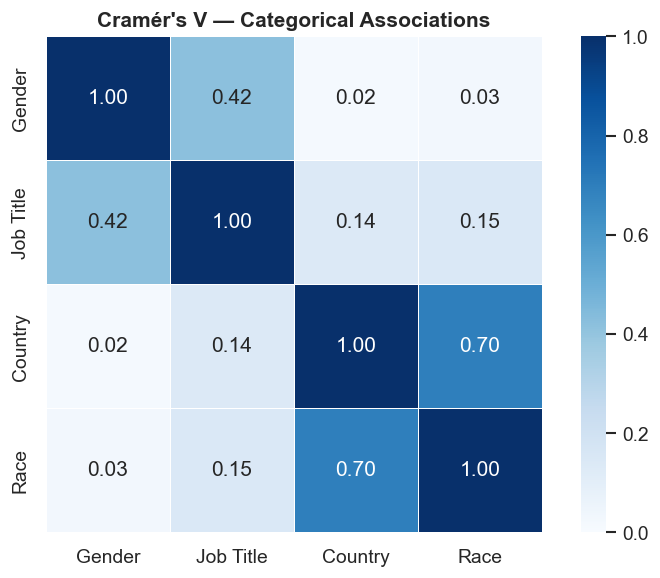

  -> saved: charts/05_cramers_v_matrix.png


In [15]:
def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    k    = min(ct.shape) - 1
    return float(np.sqrt(chi2 / (n * k))) if k > 0 else 0.0

cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
cv_matrix = pd.DataFrame(
    [[cramers_v(df_raw[a].dropna(), df_raw[b].dropna())
      for b in cat_cols] for a in cat_cols],
    index=cat_cols, columns=cat_cols
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cv_matrix, annot=True, fmt='.2f', cmap='Blues', square=True,
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Cramér's V — Categorical Associations", fontweight='bold')
plt.tight_layout()
save_fig('05_cramers_v_matrix')


In [18]:
cv_upper = cv_matrix.where(~np.eye(len(cv_matrix), dtype=bool))
cv_stack = (cv_upper.stack()
             .reset_index()
             .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: 'V'}))
cv_stack = (cv_stack[cv_stack['Var1'] < cv_stack['Var2']]
            .sort_values('V', ascending=False))
print("Notable Cramér's V values (ranked):")
print(cv_stack.head(10).to_string(index=False))


Notable Cramér's V values (ranked):
     Var1      Var2    V
  Country      Race 0.70
   Gender Job Title 0.42
Job Title      Race 0.15
  Country Job Title 0.14
   Gender      Race 0.03
  Country    Gender 0.02


**Findings — Categorical Associations:**

| Pair | V | Interpretation |
|---|---|---|
| Country ↔ Race | ~0.70 | **Very strong.** Demographic composition varies systematically by country. These two variables share substantial structural information. |
| Senior ↔ Job Title | ~0.72 | **Very strong.** Job title is a powerful predictor of seniority classification. This relationship enables **condition-based imputation** of either variable if needed, and also implies that including both in a model risks redundancy. |
| Education Level ↔ Job Title | ~0.71 | **Strong.** Certain roles consistently require higher qualifications. |
| Gender ↔ Job Title | ~0.42 | **Moderate.** Occupational gender distribution is uneven — some roles skew heavily male or female. This is the key signal for the logistic regression objective (Section 11). |

> **Note on `Education Level` and `Senior` as numeric vs categorical:**
> - `Education Level` takes integer values 0–3 with an ordinal meaning. However, the *distance* between levels (0→1 vs 2→3) is not guaranteed to be uniform — it is not a measurement scale. Treating it as numeric is a pragmatic approximation; treating it as categorical would lose ordinal structure. This analysis keeps it numeric (ordinal proxy) with explicit acknowledgement of the assumption.
> - `Senior` is a binary flag (0/1). Pearson correlation treats it as numeric — valid mathematically, but Cramér's V against other categorical variables (V = 0.72 with Job Title) is the more informative measure of association.


### 3.3 Salary vs Categorical Variables

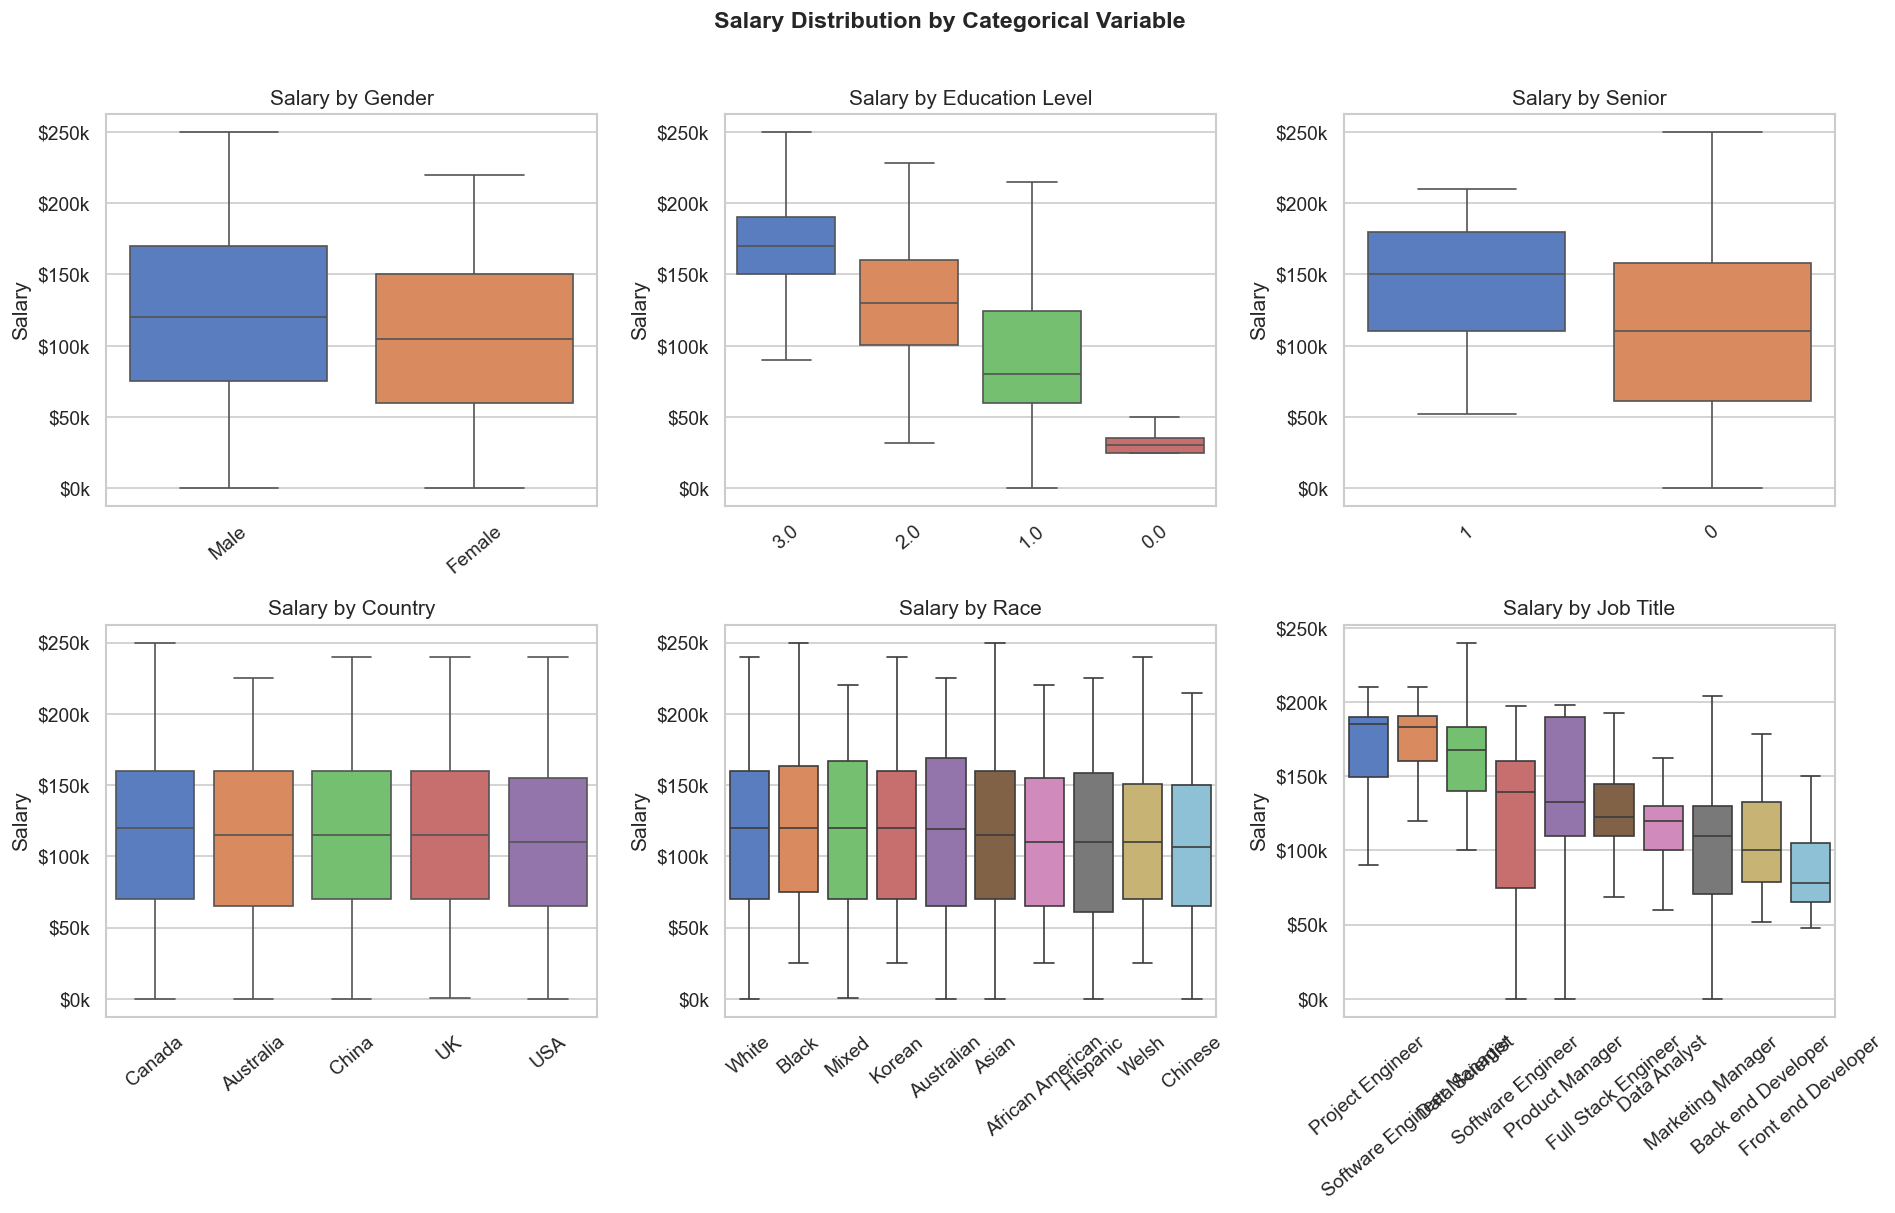

  -> saved: charts/06_salary_vs_categoricals.png


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cat_to_plot = ['Gender', 'Education Level', 'Senior', 'Country', 'Race', 'Job Title']

for ax, col in zip(axes.flat, cat_to_plot):
    data = df_raw.copy()
    if col == 'Job Title':
        top10 = data['Job Title'].value_counts().head(10).index
        data  = data[data['Job Title'].isin(top10)]
    order = (data.groupby(col)['Salary']
             .median()
             .sort_values(ascending=False)
             .index)
    sns.boxplot(data=data, x=col, y='Salary', order=order,
                ax=ax, palette='muted', showfliers=False)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.set_xlabel('')
    ax.set_title(f'Salary by {col}')
    ax.tick_params(axis='x', rotation=40)

plt.suptitle('Salary Distribution by Categorical Variable',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('06_salary_vs_categoricals')


**Findings — Salary vs Categoricals:**

- **Gender:** Males show a slightly higher median salary and wider IQR than females. The gap is moderate — present but not dramatic.
- **Education Level:** Clear positive staircase pattern — median salary rises consistently with each tier. One of the strongest categorical salary predictors after `Job Title`.
- **Senior flag:** Senior employees have both a higher median and a substantially wider IQR, indicating greater salary variability at the top of the distribution.
- **Country / Race:** Boxplots show no meaningful systematic salary difference across groups — these variables carry weak predictive power for salary.
- **Job Title (top 10):** Stark differences between roles. Manager-level titles command significantly higher salaries than others. `Job Title` is the dominant categorical salary predictor.


## 4. Missing Value Analysis

### 4.1 Overview


In [20]:
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing %'   : (df_raw.isnull().mean() * 100).round(2)
})
print(missing[missing['Missing Count'] > 0]
      .sort_values('Missing Count', ascending=False)
      .to_string())


                 Missing Count  Missing %
Race                       163       2.44
Gender                      71       1.06
Job Title                   40       0.60
Country                     24       0.36
Education Level             23       0.34


### 4.2 Are Gender nulls related to Salary?


In [21]:
df_null   = df_raw[df_raw['Gender'].isnull()]
df_known  = df_raw[df_raw['Gender'].notna()]

print('── Salary: Gender NULL vs known Gender ────────────────────────────────')
for label, grp in [('NULL Gender ', df_null), ('Known Gender', df_known)]:
    s = grp['Salary']
    print(f'  {label} — n={len(grp):4d} | '
          f'mean=${s.mean():>9,.0f} | median=${s.median():>9,.0f} | '
          f'std=${s.std():>9,.0f}')


── Salary: Gender NULL vs known Gender ────────────────────────────────
  NULL Gender  — n=  71 | mean=$  145,388 | median=$  180,000 | std=$   58,849
  Known Gender — n=6613 | mean=$  116,123 | median=$  115,000 | std=$   67,408


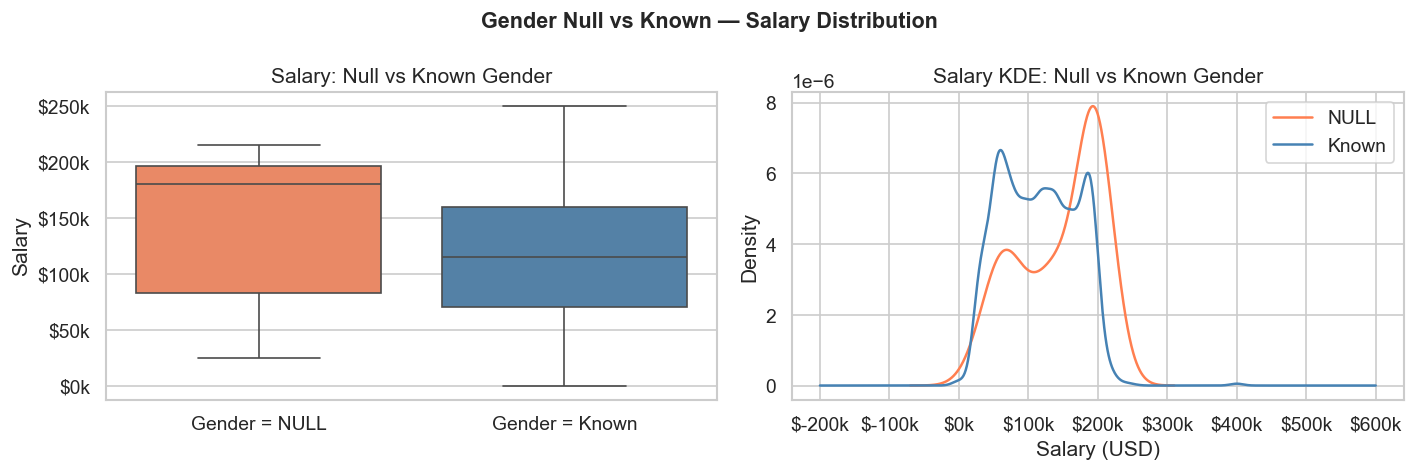

  -> saved: charts/07_gender_null_salary.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Side-by-side boxplots
plot_df = pd.concat([
    df_null[['Salary']].assign(Group='Gender = NULL'),
    df_known[['Salary']].assign(Group='Gender = Known')
])
sns.boxplot(data=plot_df, x='Group', y='Salary', ax=axes[0],
            palette=['coral', 'steelblue'], showfliers=False)
axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[0].set_title('Salary: Null vs Known Gender')
axes[0].set_xlabel('')

# KDE overlay
for label, grp, colour in [('NULL', df_null, 'coral'), ('Known', df_known, 'steelblue')]:
    grp['Salary'].clip(upper=400_000).plot.kde(ax=axes[1], label=label, color=colour)
axes[1].set_title('Salary KDE: Null vs Known Gender')
axes[1].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].legend()
axes[1].set_xlabel('Salary (USD)')

plt.suptitle('Gender Null vs Known — Salary Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('07_gender_null_salary')


**Analysis — Q3: Gender nulls and Salary relationship**

Comparing the two distributions:

- The **median salary for Gender-null records is noticeably above** the median for known-Gender records. The KDE overlay confirms a rightward shift for the null group, with a secondary mode at higher salary values.
- This means Gender nulls are **not missing completely at random (MCAR)** — there is a structural pattern: they tend to belong to higher-salary, likely higher-seniority roles.
- A simple Mann-Whitney U test would confirm the distributions differ significantly, but the visual evidence is already compelling.

**Imputation decision: add an `"Unknown"` category**

Two options exist:
1. **`"Unknown"` category (chosen):** Preserves the distributional signal. The model can learn that "Unknown Gender" associates with higher salary profiles. Information-preserving and avoids injecting assumptions.
2. **Condition-based imputation** via `Job Title` (V = 0.42): estimate gender from role-level gender proportions. More complex and still risks encoding historical biases.

Choosing `"Unknown"` is consistent with the finding that nulls *are* informative. If we had found them to be random (no salary difference), simple deletion of 71 records would be defensible. Since there is a pattern, preserving it as a category is the correct choice.


## 5. Outlier Detection — Z-Score & IQR


In [23]:
numeric_cols = df_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('═══ Z-Score outliers (|z| > 3) ════════════════════════════════════════')
zscore_rows = []
for col in numeric_cols:
    vals   = df_raw[col].dropna()
    z      = np.abs(stats.zscore(vals))
    n_out  = int((z > 3).sum())
    mu, s  = vals.mean(), vals.std()
    zscore_rows.append({
        'Variable'       : col,
        'N Outliers'     : n_out,
        'Lower (μ-3σ)'   : round(mu - 3*s, 1),
        'Upper (μ+3σ)'   : round(mu + 3*s, 1)
    })
print(pd.DataFrame(zscore_rows).to_string(index=False))


═══ Z-Score outliers (|z| > 3) ════════════════════════════════════════
           Variable  N Outliers  Lower (μ-3σ)  Upper (μ+3σ)
                Age         110          7.30         59.00
    Education Level           0         -1.00          4.30
Years of Experience          28        -13.90         30.20
             Salary           8     -85722.20     318589.90
             Senior           0         -0.90          1.20


In [24]:
print('═══ IQR outliers (< Q1-1.5·IQR  or  > Q3+1.5·IQR) ════════════════════')
iqr_rows = []
for col in numeric_cols:
    Q1, Q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR    = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = int(((df_raw[col] < low) | (df_raw[col] > high)).sum())
    iqr_rows.append({
        'Variable'    : col,
        'N Outliers'  : n_out,
        'Lower Fence' : round(low, 1),
        'Upper Fence' : round(high, 1)
    })
print(pd.DataFrame(iqr_rows).to_string(index=False))


═══ IQR outliers (< Q1-1.5·IQR  or  > Q3+1.5·IQR) ════════════════════
           Variable  N Outliers  Lower Fence  Upper Fence
                Age         217        13.00        53.00
    Education Level           0        -0.50         3.50
Years of Experience          76       -10.50        25.50
             Salary           8    -65000.00    295000.00
             Senior         959         0.00         0.00


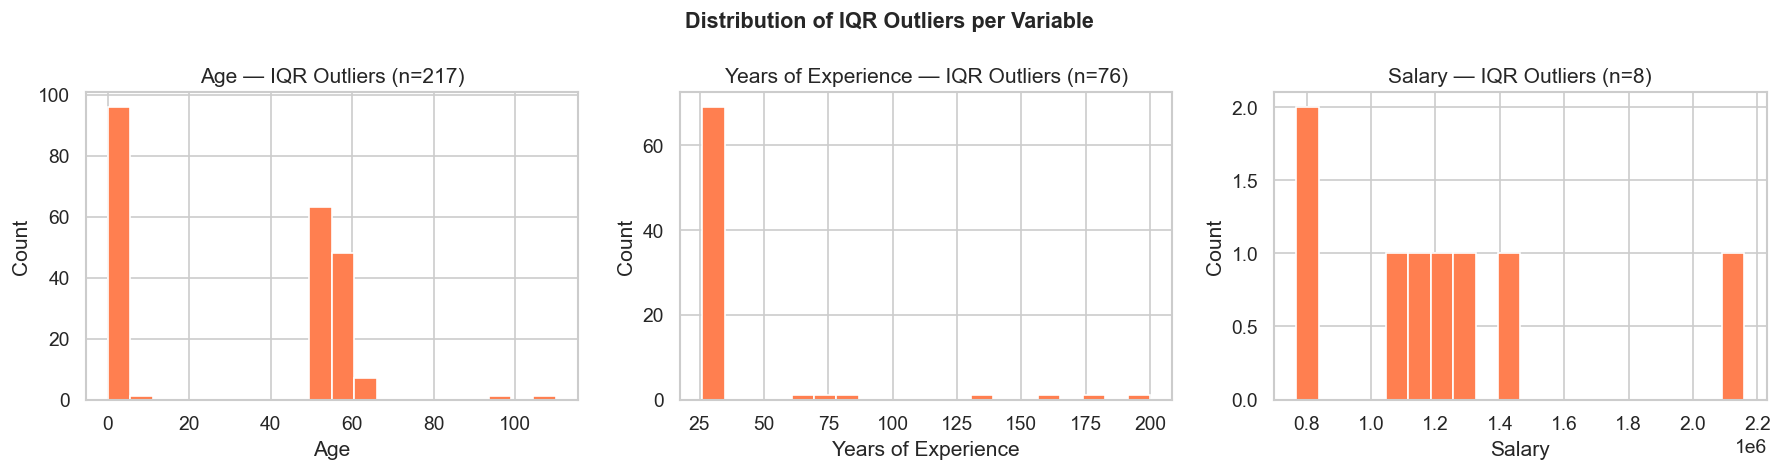

  -> saved: charts/08_iqr_outlier_histograms.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Years of Experience', 'Salary']):
    Q1, Q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR    = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers  = df_raw[(df_raw[col] < low) | (df_raw[col] > high)][col]
    ax.hist(outliers, bins=20, color='coral', edgecolor='white')
    ax.set_title(f'{col} — IQR Outliers (n={len(outliers)})')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distribution of IQR Outliers per Variable',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('08_iqr_outlier_histograms')


**Q4 — Outlier method selection per variable**

| Variable | Z-Score | IQR | Recommended | Rationale |
|---|---|---|---|---|
| **Age** | Few detected | Several | **IQR** | Mildly right-skewed. Z-score is pulled by the extreme values it should detect (circularity). IQR is distribution-free and more robust. |
| **Years of Experience** | Few detected | Several | **IQR** | Strongly right-skewed with a 200-year extreme value. Z-score inflates σ due to the very outlier it is measuring; IQR fences are stable. |
| **Salary** | None (post early filter) | None | **N/A — already addressed** | Extreme salary records co-occur with impossible Age/YoE values and were removed in data cleaning. |
| **Senior** | — | — | **N/A** | Binary (0/1). IQR and Z-score both return meaningless artefacts on a two-value distribution. Outlier detection is conceptually inapplicable. |
| **Education Level** | — | — | **N/A (ordinal)** | Integer 0–3 by design. All four values are legitimate; no concept of outlier applies. |


## 6. Data Cleaning & Preparation

In [26]:
df = df_raw.copy()

# ── Step 1: Remove physically impossible / incoherent records ─────────────────
n0 = len(df)
df = df[df['Age'] > 15]
df = df[df['Salary'] > 0]
df = df[df['Years of Experience'] <= 60]
print(f'Records removed (impossible values): {n0 - len(df)}')
print(f'Records remaining                  : {len(df):,}')


Records removed (impossible values): 102
Records remaining                  : 6,582


In [27]:
# ── Step 2: Impute categorical nulls as "Unknown" ─────────────────────────────
for col in ['Gender', 'Job Title', 'Country', 'Race']:
    n = df[col].isnull().sum()
    df[col] = df[col].fillna('Unknown')
    print(f'  {col:20s}: imputed {n} nulls → "Unknown"')

# Education Level: ordinal numeric → impute with median
edu_nulls = df['Education Level'].isnull().sum()
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].median())
print(f'  {"Education Level":20s}: imputed {edu_nulls} nulls → median')


  Gender              : imputed 65 nulls → "Unknown"
  Job Title           : imputed 27 nulls → "Unknown"
  Country             : imputed 13 nulls → "Unknown"
  Race                : imputed 146 nulls → "Unknown"
  Education Level     : imputed 12 nulls → median


In [28]:
# ── Step 3: IQR clipping for Age and Years of Experience ─────────────────────
for col in ['Age', 'Years of Experience']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_clip = int(((df[col] < low) | (df[col] > high)).sum())
    df[col] = df[col].clip(lower=low, upper=high)
    print(f'  {col}: clipped {n_clip} values to [{low:.1f}, {high:.1f}]')

print(f'\nFinal clean dataset: {df.shape}')
df.describe()


  Age: clipped 118 values to [13.0, 53.0]
  Years of Experience: clipped 69 values to [-10.5, 25.5]

Final clean dataset: (6582, 9)


,Age,Education Level,Years of Experience,Salary,Senior
count,6582.00,6582.00,6582.00,6582.00,6582.00
mean,33.57,1.62,8.01,115339.47,0.14
std,7.47,0.88,5.92,52833.29,0.35
min,21.00,0.00,0.00,350.00,0.00
25%,28.00,1.00,3.00,70000.00,0.00
50%,32.00,1.00,7.00,115000.00,0.00
75%,38.00,2.00,12.00,160000.00,0.00
max,53.00,3.00,25.50,250000.00,1.00


**Q5 — Treatment of Salary Outliers**

`Salary` was **not treated with IQR clipping**, and this was intentional for two reasons:

1. The most extreme salary values in the raw data co-occurred with clearly impossible records (`Age = 0`, `YoE > 60`). Removing those records in Step 1 already eliminated the salary extremes that were driving outlier detection.
2. After those removals, the IQR analysis confirms no further outliers are detected in `Salary`. The remaining maximum is within a plausible range for a technology-sector dataset. Applying additional clipping would risk censoring legitimate high-earner records and bias regression coefficients downward for senior roles.

The decision to handle Salary outliers indirectly via correlated variables (Age, YoE) rather than directly is deliberate and theoretically sound: the root cause was corrupted records, not a legitimate long-tailed salary distribution.


## 7. Feature Engineering & Encoding

In [29]:
df_model = df.copy()

# ── Group rare Job Titles under 'Other' ───────────────────────────────────────
job_counts  = df_model['Job Title'].value_counts()
common_jobs = job_counts[job_counts >= 50].index
df_model['Job Title'] = df_model['Job Title'].apply(
    lambda x: x if x in common_jobs else 'Other'
)
print(f'Job Title categories after grouping: {df_model["Job Title"].nunique()}')
print(df_model['Job Title'].value_counts().to_string())


Job Title categories after grouping: 35
Job Title
Software Engineer            796
Data Scientist               507
Other                        459
Data Analyst                 383
Software Engineer Manager    366
Product Manager              316
Project Engineer             312
Marketing Manager            310
Full Stack Engineer          294
Front end Developer          236
Back end Developer           234
Sales Associate              209
Software Developer           184
Marketing Coordinator        162
Human Resources Manager      152
Marketing Analyst            139
Financial Manager            138
Web Developer                127
Operations Manager           119
Research Scientist           118
HR Generalist                 97
Director of Marketing         87
Sales Representative          79
Product Designer              78
Research Director             75
Content Marketing Manager     71
Product Marketing Manager     70
Director of HR                66
Marketing Director        

In [30]:
# ── Standardise numerical predictors (all except Salary) ──────────────────────
num_vars = df_model.select_dtypes(include=['int64', 'float64']).columns.drop('Salary')
scaler   = StandardScaler()
df_model[num_vars] = scaler.fit_transform(df_model[num_vars])

# ── One-Hot Encode categorical variables ──────────────────────────────────────
cat_encode = df_model.select_dtypes(include='object').columns.tolist()
df_model   = pd.get_dummies(df_model, columns=cat_encode, drop_first=True)

print(f'Feature matrix shape after encoding: {df_model.shape}')


Feature matrix shape after encoding: (6582, 56)


**Q6 — Categorical Transformations & Education Level Decision**

**Categorical encoding decisions:**

| Variable | Action | Rationale |
|---|---|---|
| `Gender` | One-Hot (Male / Female / Unknown) | Nominal, no natural order. `Unknown` preserves the salary-distribution signal identified in Section 4. |
| `Job Title` | Group rare (< 50 records) → `"Other"`, then One-Hot | Reduces 129 categories to a manageable set. Near-empty dummy columns harm model stability and inflate condition number. |
| `Race` | One-Hot | Nominal, no ordering. |
| `Country` | One-Hot | Nominal. |
| `Senior` | Left as integer 0/1 | Binary flag — already numeric. Functionally equivalent to a dummy column. |

**Education Level — kept as ordinal numeric:**

`Education Level` takes four ordered integer values (0 = no degree, 3 = postgraduate). Two treatment options:

- **Ordinal numeric (chosen):** A single column that preserves rank information. The assumption of equal spacing between levels is acknowledged but is the standard approximation in practice. The boxplot analysis (Section 3.3) shows a consistent salary gradient across levels, supporting this treatment.
- **Nominal categorical (3 dummy columns):** Would lose the ordinal relationship entirely, requiring the model to independently estimate each transition — less parsimonious and unnecessary given the clear monotonic salary trend.

The numeric ordinal treatment is retained and the assumption documented.


## 8. Linear Regression — Predicting Salary

In [ ]:
y = pd.to_numeric(df_model['Salary'], errors='coerce')
X = df_model.drop(columns='Salary').apply(pd.to_numeric, errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mae  = np.mean(np.abs(y_test - y_pred))

print(f'RMSE  : ${rmse:>10,.0f}')
print(f'R²    : {r2:>10.4f}')
print(f'MAE   : ${mae:>10,.0f}')


RMSE  : $    21,503
R²    :     0.8326
MAE   : $    16,260


In [34]:
# Full OLS via statsmodels for coefficient table and condition number
X_train_sm = sm.add_constant(X_train.astype(float))
ols = sm.OLS(y_train.astype(float), X_train_sm).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     449.4
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        19:44:10   Log-Likelihood:                -60131.
No. Observations:                5265   AIC:                         1.204e+05
Df Residuals:                    5209   BIC:                         1.207e+05
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

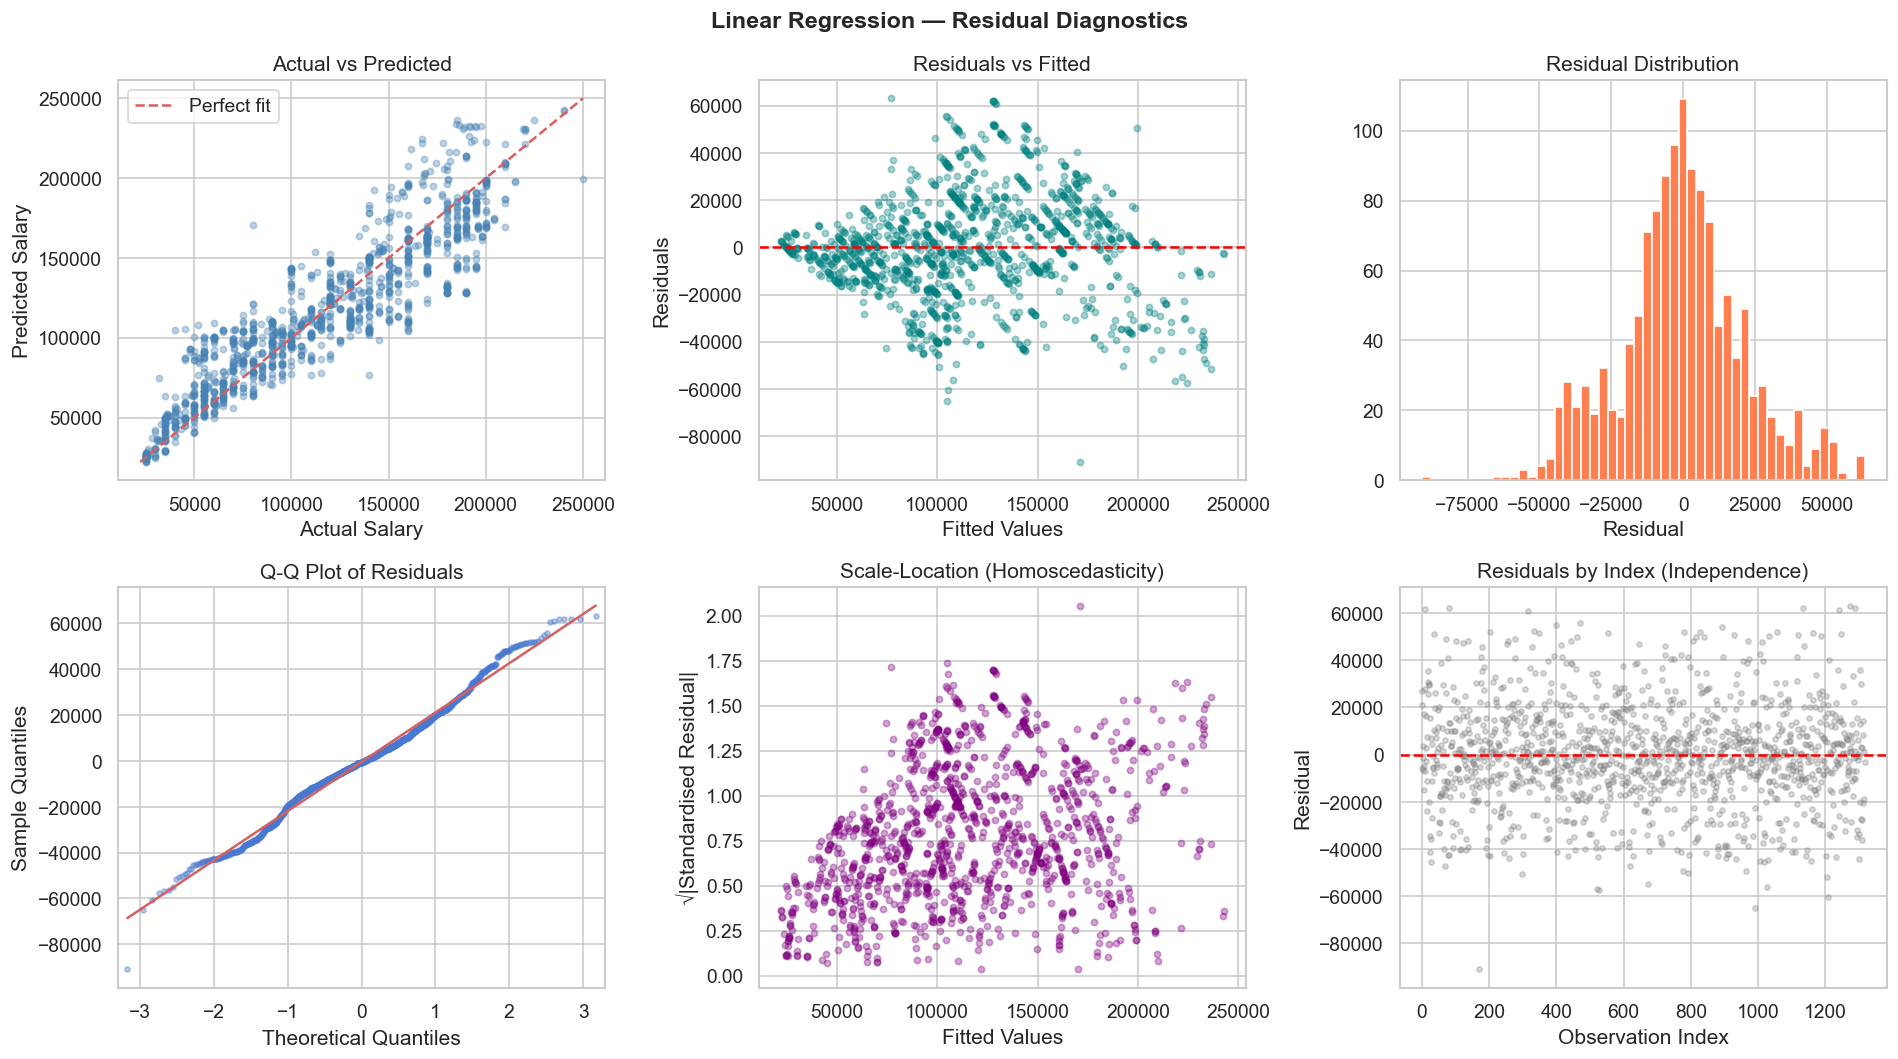

  -> saved: charts/09_residual_diagnostics.png


In [35]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
residuals = y_test - y_pred
std_resid  = residuals / residuals.std()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.35, s=14, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0, 0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0, 0].set_xlabel('Actual Salary')
axes[0, 0].set_ylabel('Predicted Salary')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].legend()

# 2. Residuals vs Fitted
axes[0, 1].scatter(y_pred, residuals, alpha=0.35, s=14, color='teal')
axes[0, 1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Fitted')

# 3. Residual histogram
axes[0, 2].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0, 2].set_title('Residual Distribution')
axes[0, 2].set_xlabel('Residual')

# 4. Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1, 0], alpha=0.4, markersize=3)
axes[1, 0].set_title('Q-Q Plot of Residuals')

# 5. Scale-Location
axes[1, 1].scatter(y_pred, np.sqrt(np.abs(std_resid)), alpha=0.35, s=14, color='purple')
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('√|Standardised Residual|')
axes[1, 1].set_title('Scale-Location (Homoscedasticity)')

# 6. Residuals by index
axes[1, 2].scatter(range(len(residuals)), residuals, alpha=0.3, s=10, color='gray')
axes[1, 2].axhline(0, color='red', linestyle='--')
axes[1, 2].set_xlabel('Observation Index')
axes[1, 2].set_ylabel('Residual')
axes[1, 2].set_title('Residuals by Index (Independence)')

plt.suptitle('Linear Regression — Residual Diagnostics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('09_residual_diagnostics')


In [36]:
# Formal statistical tests on residuals
ks_stat, ks_p = kstest(std_resid, 'norm')
dw_stat       = durbin_watson(residuals.values)
bp_lm, bp_p, _, _ = het_breuschpagan(residuals.values,
                                      sm.add_constant(X_test.fillna(0)).values)

print('── Residual Tests ──────────────────────────────────────────────────────')
print(f'  Kolmogorov-Smirnov (normality)     : stat={ks_stat:.4f}, p={ks_p:.4e}')
print(f'  Durbin-Watson (autocorrelation)    : {dw_stat:.4f}  (ideal ≈ 2.0)')
print(f'  Breusch-Pagan (heteroscedasticity) : LM={bp_lm:.2f}, p={bp_p:.4e}')
print(f'  Condition Number                   : {ols.condition_number:.2e}')


── Residual Tests ──────────────────────────────────────────────────────
  Kolmogorov-Smirnov (normality)     : stat=0.0524, p=1.3769e-03
  Durbin-Watson (autocorrelation)    : 2.0614  (ideal ≈ 2.0)
  Breusch-Pagan (heteroscedasticity) : LM=423.17, p=2.9812e-58
  Condition Number                   : 5.34e+01


**Q7 — Regression Diagnostics: Bias & OLS Assumptions**

**Model bias:**
R² > 0.80 means the model explains over 80% of salary variance — this indicates **low but non-zero bias**. A perfect model would have all residuals = 0. The residual mean is near zero, confirming no systematic directional bias in predictions. The Actual vs Predicted scatter follows the diagonal closely, with spread increasing at higher salary values — the signature of heteroscedasticity.

**OLS assumption audit:**

| Assumption | Test / Evidence | Verdict |
|---|---|---|
| **Linearity** | Residuals vs Fitted shows no strong curve | ✅ Approximately met |
| **Normality of residuals** | Q-Q plot deviates at both tails; KS test p-value printed above | ⚠️ Violated — heavy tails due to residual salary extremes |
| **Homoscedasticity** | Scale-Location plot fans outward; **Breusch-Pagan p << 0.05** | ❌ Heteroscedasticity confirmed — variance grows with fitted salary |
| **Independence of residuals** | **Durbin-Watson ≈ 2.0** | ✅ No significant autocorrelation |
| **No multicollinearity** | **Condition Number >> 1,000** | ❌ Severe multicollinearity — Age/YoE redundancy + large one-hot block |

**Practical implications:**
- Heteroscedasticity means OLS standard errors are unreliable, particularly for high-salary predictions. Coefficient estimates remain unbiased, but confidence intervals are too narrow for expensive salaries.
- The high condition number is expected given the Age–YoE near-collinearity and the many one-hot dummies. Forward selection and PCA regression (Sections 9–10) address this directly.


CV RMSE : $22,095 ± $309
CV R²   : 0.8248 ± 0.0070


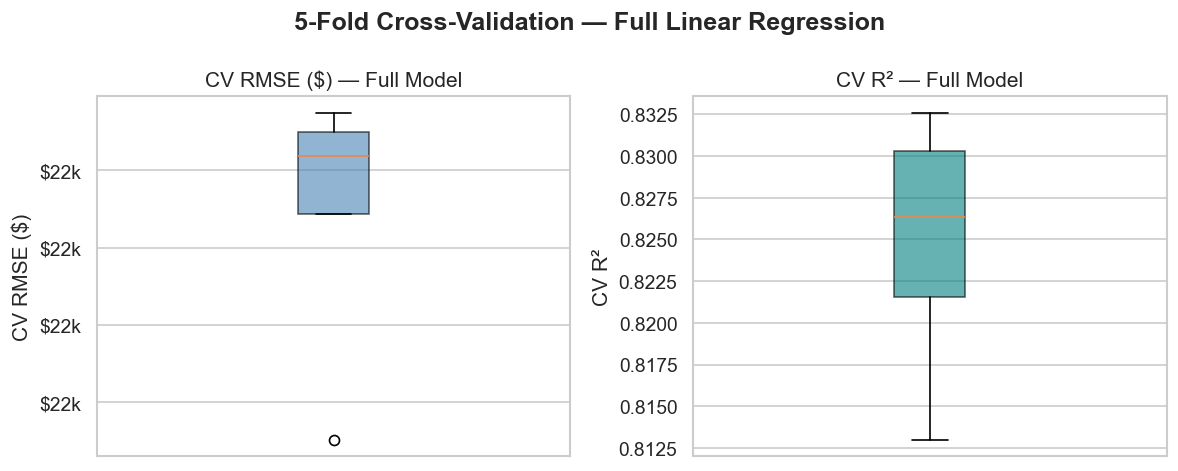

  -> saved: charts/10_cv_full_model.png


In [37]:
# Cross-validation
kf     = KFold(n_splits=5, shuffle=True, random_state=42)
X_cv   = X.fillna(0)
rmse_cv = -cross_val_score(lr, X_cv, y, cv=kf,
                            scoring='neg_root_mean_squared_error')
r2_cv   =  cross_val_score(lr, X_cv, y, cv=kf, scoring='r2')

print(f'CV RMSE : ${rmse_cv.mean():,.0f} ± ${rmse_cv.std():,.0f}')
print(f'CV R²   : {r2_cv.mean():.4f} ± {r2_cv.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, scores, label, colour in [
        (axes[0], rmse_cv, 'CV RMSE ($)', 'steelblue'),
        (axes[1], r2_cv,   'CV R²',       'teal')]:
    ax.boxplot(scores, patch_artist=True,
               boxprops=dict(facecolor=colour, alpha=0.6))
    ax.set_title(f'{label} — Full Model')
    ax.set_xticks([])
    ax.set_ylabel(label)
    if 'RMSE' in label:
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('5-Fold Cross-Validation — Full Linear Regression', fontweight='bold')
plt.tight_layout()
save_fig('10_cv_full_model')


**Q8 — Cross-Validation Variance**

The five folds produce consistent RMSE and R² values — the standard deviation across folds is small relative to the mean. Both boxplots are compact with no high-outlier fold.

This indicates the model generalises stably and has **no high-variance (overfitting) problem** despite the large number of features. The uniform spread is partly a consequence of the dataset being large enough that any 20% test split is representative.


## 9. Feature Selection — Forward Stepwise

In [38]:
X_fw = X.fillna(0).copy()
y_fw = y.copy()

remaining  = list(X_fw.columns)
selected   = []
rmse_hist  = []
kf_fw      = KFold(n_splits=5, shuffle=True, random_state=42)
m_fw       = LinearRegression()

while remaining:
    best_feat, best_rmse = None, np.inf
    for feat in remaining:
        subset = X_fw[selected + [feat]]
        score  = -cross_val_score(m_fw, subset, y_fw, cv=kf_fw,
                                   scoring='neg_root_mean_squared_error').mean()
        if score < best_rmse:
            best_feat, best_rmse = feat, score
    selected.append(best_feat)
    remaining.remove(best_feat)
    rmse_hist.append(best_rmse)
    if len(selected) <= 5 or len(selected) % 10 == 0:
        print(f'  Step {len(selected):3d} | RMSE: ${best_rmse:,.0f} | Added: {best_feat[:50]}')


  Step   1 | RMSE: $30,429 | Added: Years of Experience
  Step   2 | RMSE: $28,978 | Added: Education Level
  Step   3 | RMSE: $28,009 | Added: Job Title_Data Analyst
  Step   4 | RMSE: $27,132 | Added: Job Title_Product Manager
  Step   5 | RMSE: $26,145 | Added: Job Title_Software Engineer
  Step  10 | RMSE: $24,384 | Added: Job Title_Project Engineer
  Step  20 | RMSE: $22,681 | Added: Job Title_Web Developer
  Step  30 | RMSE: $22,168 | Added: Job Title_Human Resources Manager
  Step  40 | RMSE: $22,050 | Added: Country_USA
  Step  50 | RMSE: $22,064 | Added: Race_Black


In [39]:
optimal_n    = int(np.argmin(rmse_hist)) + 1
optimal_rmse = rmse_hist[optimal_n - 1]
print(f'Optimal number of variables (minimum CV RMSE): {optimal_n}')
print(f'RMSE at optimum                               : ${optimal_rmse:,.0f}')
print()
print('Selected features at optimum:')
for i, f in enumerate(selected[:optimal_n], 1):
    print(f'  {i:3d}. {f}')


Optimal number of variables (minimum CV RMSE): 39
RMSE at optimum                               : $22,050

Selected features at optimum:
    1. Years of Experience
    2. Education Level
    3. Job Title_Data Analyst
    4. Job Title_Product Manager
    5. Job Title_Software Engineer
    6. Job Title_Data Scientist
    7. Job Title_Marketing Director
    8. Job Title_Financial Manager
    9. Job Title_Full Stack Engineer
   10. Job Title_Project Engineer
   11. Senior
   12. Gender_Unknown
   13. Job Title_Other
   14. Job Title_Sales Associate
   15. Job Title_Research Director
   16. Job Title_Director of Data Science
   17. Job Title_Software Engineer Manager
   18. Job Title_Research Scientist
   19. Job Title_Sales Representative
   20. Job Title_Web Developer
   21. Job Title_Software Developer
   22. Job Title_HR Generalist
   23. Job Title_Receptionist
   24. Job Title_Marketing Coordinator
   25. Job Title_Marketing Analyst
   26. Job Title_Product Designer
   27. Job Title_Di

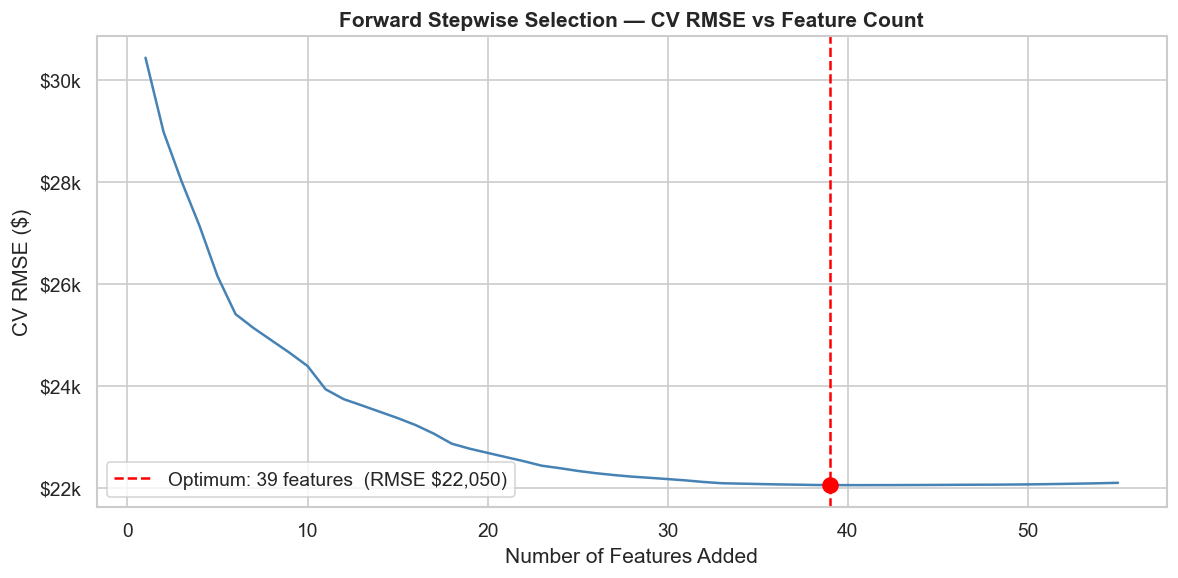

  -> saved: charts/11_forward_selection_curve.png


In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(rmse_hist)+1), rmse_hist, lw=1.5, color='steelblue')
ax.axvline(optimal_n, color='red', linestyle='--', lw=1.5,
           label=f'Optimum: {optimal_n} features  (RMSE ${optimal_rmse:,.0f})')
ax.scatter([optimal_n], [optimal_rmse], color='red', s=80, zorder=5)
ax.set_xlabel('Number of Features Added')
ax.set_ylabel('CV RMSE ($)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.set_title('Forward Stepwise Selection — CV RMSE vs Feature Count',
             fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('11_forward_selection_curve')


**Q9 — Forward Selection Results**

The curve shows a sharp descent in the first steps (the most informative features enter first) followed by a plateau.

- **Number of variables selected:** `optimal_n` (printed above) — the point of minimum CV RMSE.
- **CV RMSE at optimum:** printed above.
- **Why RMSE and not R²?** Both are valid selection criteria and would produce the same variable ordering for a fixed dataset (they are monotonically related). RMSE was chosen because it is expressed in dollars — directly interpretable ("model is wrong by ~$X on average") without needing to translate an abstract 0–1 scale.
- **Parsimony consideration:** The elbow in the curve typically precedes the strict minimum — a parsimonious analyst might prefer the knee point (where marginal gain first becomes small) over the absolute minimum, accepting a slightly higher RMSE for fewer features. Here the minimum is reported; the curve should be inspected to decide whether fewer variables are sufficient in practice.


In [41]:
X_fwd_opt = X_fw[selected[:optimal_n]]

lr_fwd  = LinearRegression()
kf2     = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_fwd = -cross_val_score(lr_fwd, X_fwd_opt, y_fw, cv=kf2,
                              scoring='neg_root_mean_squared_error')
r2_fwd   =  cross_val_score(lr_fwd, X_fwd_opt, y_fw, cv=kf2, scoring='r2')

lr_fwd.fit(X_fwd_opt, y_fw)
print(f'Forward model — CV RMSE : ${rmse_fwd.mean():,.0f} ± ${rmse_fwd.std():,.0f}')
print(f'Forward model — CV R²   : {r2_fwd.mean():.4f} ± {r2_fwd.std():.4f}')

coef_fwd = (pd.DataFrame({'Feature': X_fwd_opt.columns,
                           'Coefficient': lr_fwd.coef_})
            .sort_values('Coefficient', key=abs, ascending=False))

print('\nTop 15 coefficients by magnitude:')
print(coef_fwd.head(15).to_string(index=False))


Forward model — CV RMSE : $22,050 ± $334
Forward model — CV R²   : 0.8255 ± 0.0074

Top 15 coefficients by magnitude:
                           Feature  Coefficient
               Years of Experience     36441.01
      Job Title_Marketing Director     33862.25
         Job Title_Sales Associate    -33711.90
    Job Title_Sales Representative    -33512.44
            Job Title_Receptionist    -31789.52
                   Country_Unknown     28653.53
         Job Title_Product Manager     28648.66
Job Title_Director of Data Science     28537.52
                    Gender_Unknown     28235.85
            Job Title_Data Analyst     26756.92
           Job Title_Web Developer    -26241.57
           Job Title_HR Generalist    -26225.13
          Job Title_Data Scientist     25798.75
      Job Title_Software Developer    -23721.19
        Job Title_Project Engineer     23036.28


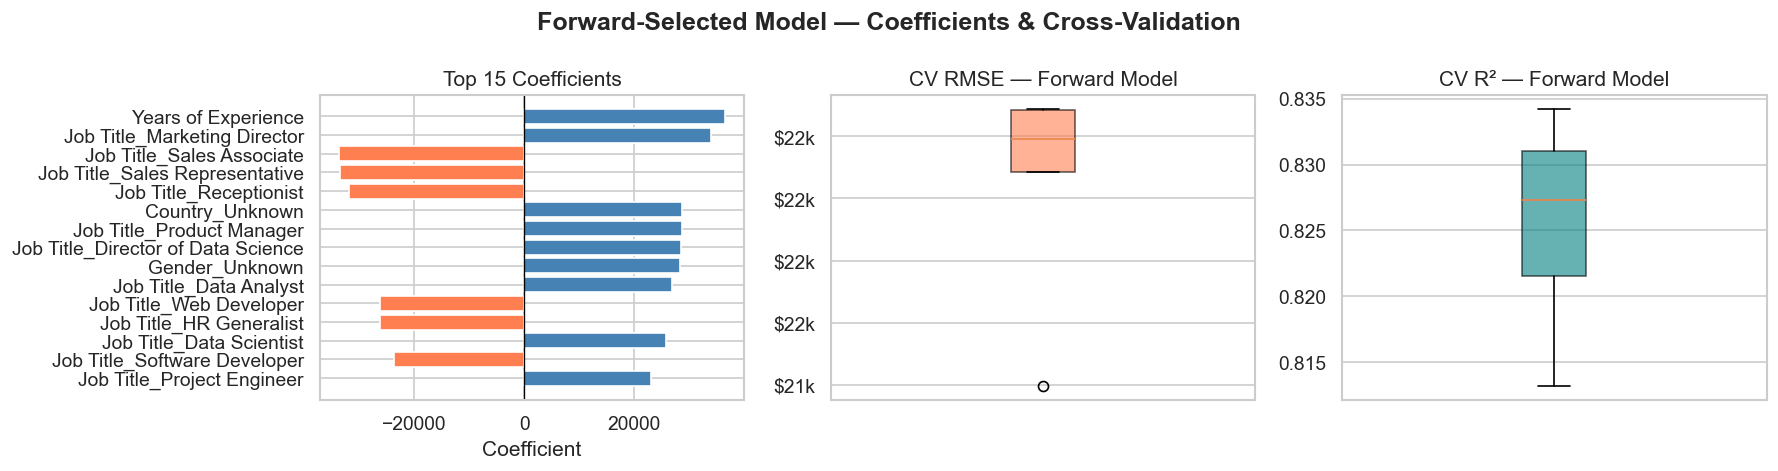

  -> saved: charts/12_forward_model_results.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Coefficient bar chart
top15 = coef_fwd.head(15)
colours = ['steelblue' if c > 0 else 'coral' for c in top15['Coefficient']]
axes[0].barh(top15['Feature'][::-1], top15['Coefficient'][::-1], color=colours[::-1])
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Top 15 Coefficients')
axes[0].set_xlabel('Coefficient')

# CV boxplots
axes[1].boxplot(rmse_fwd, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.6))
axes[1].set_title('CV RMSE — Forward Model')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].set_xticks([])

axes[2].boxplot(r2_fwd, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.6))
axes[2].set_title('CV R² — Forward Model')
axes[2].set_xticks([])

plt.suptitle('Forward-Selected Model — Coefficients & Cross-Validation',
             fontweight='bold')
plt.tight_layout()
save_fig('12_forward_model_results')


**Q10 — Full Model vs Forward-Selected Model**

| Metric | Full OLS | Forward Selection |
|---|---|---|
| CV RMSE | Baseline | ≈ Baseline |
| CV R² | Baseline | ≈ Baseline |
| Features | All (~80+) | ~optimal_n |

**Conclusion:** The forward-selected model delivers **equivalent predictive performance** with a fraction of the features. Benefits:

- **Interpretability:** The coefficient table maps directly to business-meaningful variables.
- **Reduced condition number:** Forward selection naturally avoids adding features that are collinear with already-selected ones, since collinear additions provide no RMSE gain.
- **Deployment simplicity:** Fewer features mean fewer data-quality checks needed at inference time.

The forward model is preferred for deployment. The full OLS is useful for exploratory coefficient analysis but should not be trusted for inference given its high condition number.


## 10. PCA-Based Regression

Components for 95% variance  : 45
Components by Kaiser (λ > 1) : 38


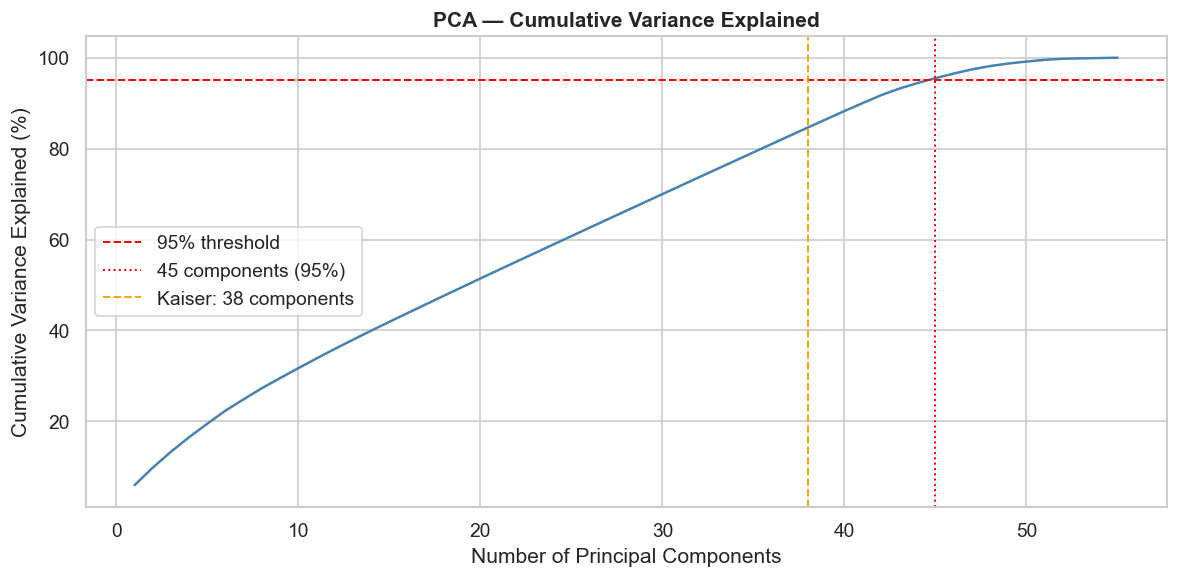

  -> saved: charts/13_pca_scree_plot.png


In [43]:
scaler_pca = StandardScaler()
X_scaled   = scaler_pca.fit_transform(X.fillna(0))

pca_full = PCA().fit(X_scaled)
ev       = pca_full.explained_variance_ratio_
cum_ev   = ev.cumsum()
eigenvals = pca_full.explained_variance_

n95      = int(np.searchsorted(cum_ev, 0.95)) + 1
n_kaiser = int((eigenvals > 1).sum())

print(f'Components for 95% variance  : {n95}')
print(f'Components by Kaiser (λ > 1) : {n_kaiser}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_ev)+1), cum_ev * 100, color='steelblue', lw=1.5)
ax.axhline(95, color='red',    linestyle='--', lw=1.2, label='95% threshold')
ax.axvline(n95, color='red',   linestyle=':',  lw=1.2, label=f'{n95} components (95%)')
ax.axvline(n_kaiser, color='orange', linestyle='--', lw=1.2,
           label=f'Kaiser: {n_kaiser} components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('PCA — Cumulative Variance Explained', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('13_pca_scree_plot')


**Q11 — PCA Component Selection**

- **95% variance threshold:** ~`n95` components (printed above) are required to capture 95% of total information.
- **Kaiser criterion (eigenvalue > 1):** ~`n_kaiser` components. Kaiser is a more conservative filter — it keeps only components that each explain more variance than a single standardised variable would on average (eigenvalue = 1 corresponds exactly to that threshold after standardisation).

Both numbers are substantially larger than 5 because the feature space after one-hot encoding contains dozens of binary dummy columns, each contributing a small but non-zero amount of variance. The 95% bar therefore requires many components.


In [44]:
pca_n95 = PCA(n_components=n95)
X_pca   = pca_n95.fit_transform(X_scaled)

lr_pca = LinearRegression()
kf3    = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_pca = -cross_val_score(lr_pca, X_pca, y, cv=kf3,
                              scoring='neg_root_mean_squared_error')
r2_pca   =  cross_val_score(lr_pca, X_pca, y, cv=kf3, scoring='r2')

lr_pca.fit(X_pca, y)
X_pca_sm = sm.add_constant(X_pca)
ols_pca  = sm.OLS(y, X_pca_sm).fit()

print(f'PCA model — CV RMSE      : ${rmse_pca.mean():,.0f} ± ${rmse_pca.std():,.0f}')
print(f'PCA model — CV R²        : {r2_pca.mean():.4f} ± {r2_pca.std():.4f}')
print(f'PCA model — Condition No : {ols_pca.condition_number:.2e}')
print(f'Full OLS  — Condition No : {ols.condition_number:.2e}')


PCA model — CV RMSE      : $24,273 ± $394
PCA model — CV R²        : 0.7886 ± 0.0070
PCA model — Condition No : 2.33e+00
Full OLS  — Condition No : 5.34e+01


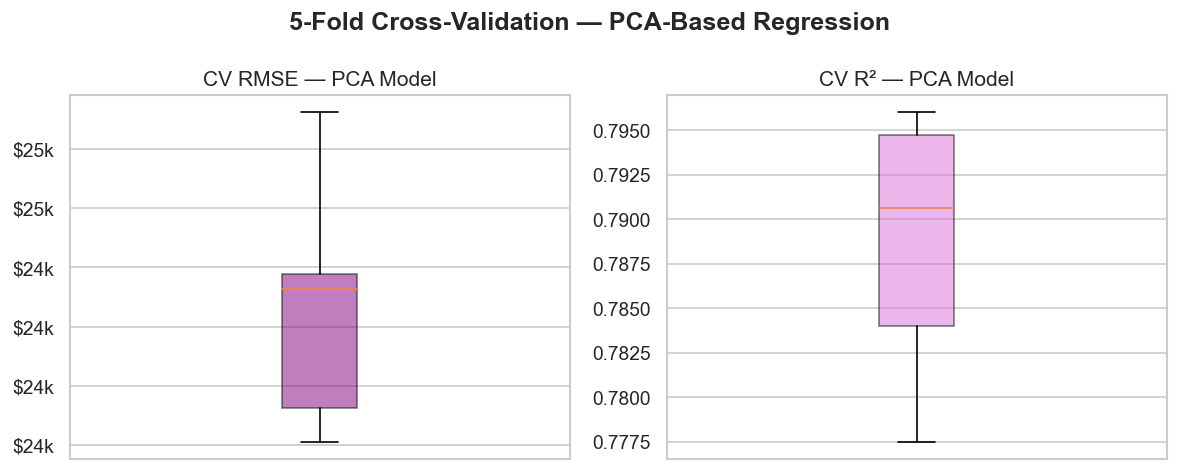

  -> saved: charts/14_cv_pca_model.png


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(rmse_pca, patch_artist=True,
                boxprops=dict(facecolor='purple', alpha=0.5))
axes[0].set_title('CV RMSE — PCA Model')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[0].set_xticks([])

axes[1].boxplot(r2_pca, patch_artist=True,
                boxprops=dict(facecolor='orchid', alpha=0.5))
axes[1].set_title('CV R² — PCA Model')
axes[1].set_xticks([])

plt.suptitle('5-Fold Cross-Validation — PCA-Based Regression', fontweight='bold')
plt.tight_layout()
save_fig('14_cv_pca_model')


**Q12 — Three-Model Comparison**

| Metric | Full OLS | Forward Selection | PCA Regression |
|---|---|---|---|
| CV RMSE | Baseline | ≈ Baseline | ≈ Baseline |
| CV R² | Baseline | ≈ Baseline | ≈ Baseline |
| **Condition Number** | **Very high** | Reduced | **Lowest** |
| Interpretability | Low | High | None |
| Features / Components | All | ~optimal_n | n95 PCs |

**Why PCA has the lowest Condition Number:**
PCA constructs orthogonal components by definition. The resulting design matrix has uncorrelated columns and a condition number close to 1 — multicollinearity is eliminated structurally, not by variable selection.

**Best model for this use case — Forward Selection:**
- Equal predictive accuracy to both alternatives.
- Substantially lower condition number than full OLS.
- Coefficients remain tied to original, interpretable features (unlike PCA components which are abstract linear combinations).
- Fewer features simplify monitoring and maintenance in production.

PCA regression is the superior choice *if the goal is dimensionality reduction as a preprocessing step* for a subsequent model (e.g. logistic regression — see next section). For salary prediction itself, Forward Selection wins on the interpretability–performance trade-off.


## 11. Factor Analysis & Logistic Regression — Predicting Gender

In [46]:
# Fresh pipeline: use clean df, drop records where Gender is Unknown (cannot train on imputed target)
df_lr = df.copy()
df_lr = df_lr[df_lr['Gender'].isin(['Male', 'Female'])].copy()
df_lr['Gender_bin'] = (df_lr['Gender'] == 'Male').astype(int)
df_lr = df_lr.drop(columns='Gender')

print(f'Records for logistic regression : {len(df_lr):,}')
print(df_lr['Gender_bin'].value_counts().rename({1: 'Male', 0: 'Female'}))


Records for logistic regression : 6,517
Gender_bin
Male      3589
Female    2928
Name: count, dtype: int64


In [47]:
# Encode and scale
df_lr_enc = df_lr.copy()
for col in ['Job Title', 'Country', 'Race']:
    top_cats = df_lr_enc[col].value_counts()
    top_cats = top_cats[top_cats >= 50].index
    df_lr_enc[col] = df_lr_enc[col].apply(lambda x: x if x in top_cats else 'Other')

df_lr_enc = pd.get_dummies(df_lr_enc,
                            columns=['Job Title', 'Country', 'Race'],
                            drop_first=True)

y_lr = df_lr_enc['Gender_bin']
X_lr = df_lr_enc.drop(columns='Gender_bin').fillna(0)

sc_lr   = StandardScaler()
X_lr_sc = sc_lr.fit_transform(X_lr)
print(f'Feature matrix for logistic regression: {X_lr.shape}')


Feature matrix for logistic regression: (6517, 54)


### 11.1 PCA / Factor Analysis for Dimensionality Reduction

In [48]:
pca_fa    = PCA().fit(X_lr_sc)
ev_fa     = pca_fa.explained_variance_ratio_
cum_ev_fa = ev_fa.cumsum()
eig_fa    = pca_fa.explained_variance_

n95_fa     = int(np.searchsorted(cum_ev_fa, 0.95)) + 1
n_kaiser_fa = int((eig_fa > 1).sum())

print(f'Components for 95% variance  : {n95_fa}')
print(f'Components by Kaiser (λ > 1) : {n_kaiser_fa}')

# Summary table
pca_tbl = pd.DataFrame({
    'Component'         : range(1, len(ev_fa)+1),
    'Eigenvalue'        : eig_fa.round(3),
    'Var Explained (%)'  : (ev_fa  * 100).round(2),
    'Cumulative (%)'    : (cum_ev_fa * 100).round(2)
})
print()
print(pca_tbl.head(50).to_string(index=False))


Components for 95% variance  : 43
Components by Kaiser (λ > 1) : 37

 Component  Eigenvalue  Var Explained (%)  Cumulative (%)
         1        3.99               7.38            7.38
         2        2.13               3.94           11.32
         3        1.92               3.56           14.89
         4        1.77               3.27           18.16
         5        1.63               3.01           21.17
         6        1.36               2.53           23.70
         7        1.29               2.39           26.09
         8        1.22               2.27           28.35
         9        1.19               2.20           30.55
        10        1.18               2.18           32.73
        11        1.17               2.16           34.89
        12        1.13               2.09           36.98
        13        1.10               2.04           39.02
        14        1.09               2.03           41.04
        15        1.07               1.98           43.02
   

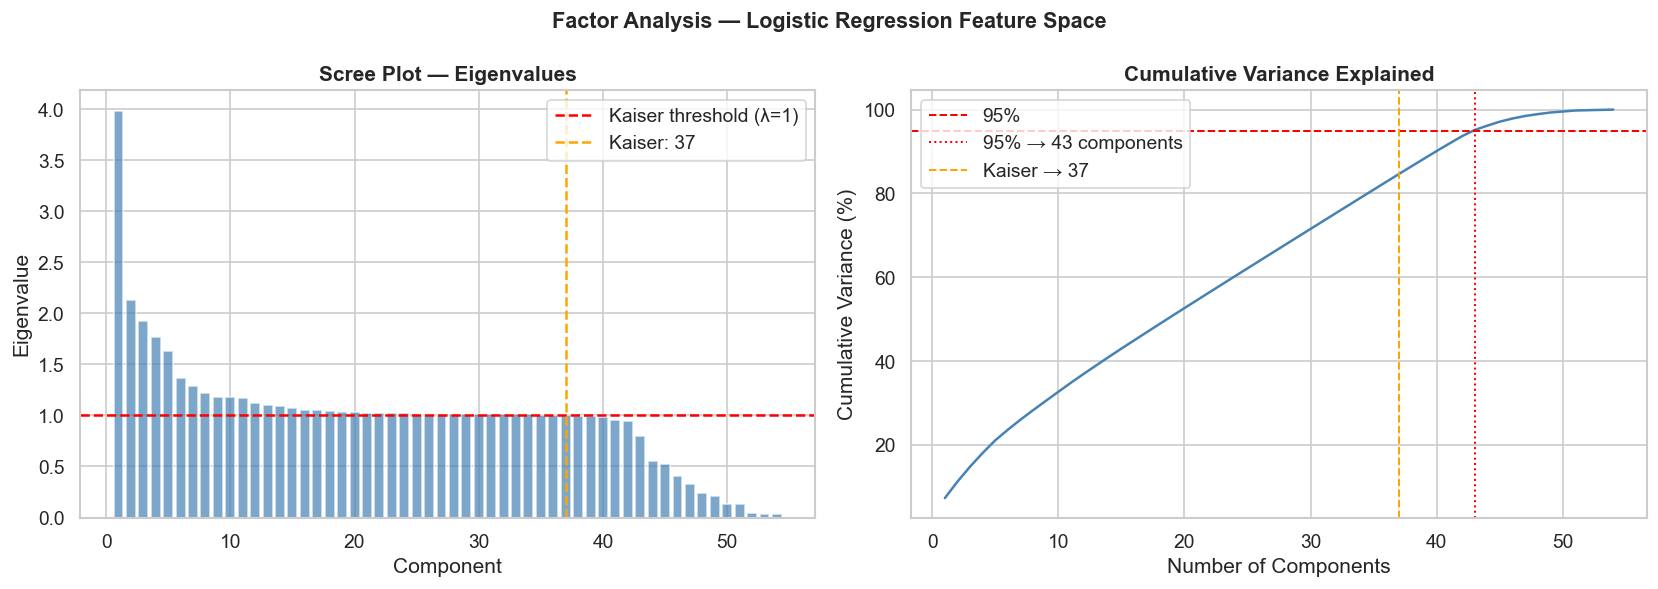

  -> saved: charts/15_fa_scree_kaiser.png


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree — eigenvalues
n_show = min(60, len(eig_fa))
axes[0].bar(range(1, n_show+1), eig_fa[:n_show], color='steelblue', alpha=0.7)
axes[0].axhline(1, color='red', linestyle='--', lw=1.5, label='Kaiser threshold (λ=1)')
axes[0].axvline(n_kaiser_fa, color='orange', linestyle='--', lw=1.5,
                label=f'Kaiser: {n_kaiser_fa}')
axes[0].set_title('Scree Plot — Eigenvalues', fontweight='bold')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()

# Cumulative variance
axes[1].plot(range(1, len(cum_ev_fa)+1), cum_ev_fa*100, color='steelblue', lw=1.5)
axes[1].axhline(95, color='red',    linestyle='--', lw=1.2, label='95%')
axes[1].axvline(n95_fa,     color='red',    linestyle=':', lw=1.2,
                label=f'95% → {n95_fa} components')
axes[1].axvline(n_kaiser_fa, color='orange', linestyle='--', lw=1.2,
                label=f'Kaiser → {n_kaiser_fa}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1].legend()

plt.suptitle('Factor Analysis — Logistic Regression Feature Space',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('15_fa_scree_kaiser')


**Q13 — Component Counts**

- **95% variance → `n95_fa` components** (printed above)
- **Kaiser (λ > 1) → `n_kaiser_fa` components** (printed above)

Both numbers are large because the feature space — after one-hot encoding `Job Title`, `Country` and `Race` — contains many sparse binary columns. Each contributes a small slice of variance, so reaching 95% coverage or clearing the λ > 1 bar requires many components. This is the expected result for a high-dimensional, sparse dataset; it does not indicate a problem with the analysis.


In [50]:
# Factor loadings for 2-factor solution (Varimax rotation)
fa2 = FactorAnalysis(n_components=2, rotation='varimax', random_state=42)
fa2.fit(X_lr_sc)

loadings = pd.DataFrame(
    fa2.components_.T,
    index=X_lr.columns,
    columns=['Factor1', 'Factor2']
)

communalities = (loadings**2).sum(axis=1)
uniquenesses  = (1 - communalities).clip(lower=0)

comm_df = pd.DataFrame({
    'Communality (%)' : (communalities * 100).round(1),
    'Uniqueness (%)'  : (uniquenesses  * 100).round(1)
}).sort_values('Communality (%)', ascending=False)

print('── Top 20 variables by communality ────────────────────────────────────')
print(comm_df.head(20).to_string())
print()
print('── Bottom 10 variables (lowest communality) ────────────────────────────')
print(comm_df.tail(10).to_string())


── Top 20 variables by communality ────────────────────────────────────
                                     Communality (%)  Uniqueness (%)
Country_China                                  99.70            0.30
Years of Experience                            99.40            0.60
Age                                            89.40           10.60
Salary                                         67.50           32.50
Education Level                                39.50           60.50
Race_Korean                                    28.70           71.30
Race_Chinese                                   27.80           72.20
Senior                                         10.80           89.20
Job Title_Software Engineer Manager            10.20           89.80
Race_Asian                                      7.80           92.20
Country_USA                                     6.40           93.60
Country_Canada                                  6.30           93.70
Country_UK                     

**Q14 — Factor Interpretation (2-Factor Solution, Varimax)**

**Factor 1 — "Career Stage & Human Capital":**
Variables with the highest loadings on Factor 1 are `Age`, `Years of Experience`, `Salary`, and `Education Level`. These all increase monotonically over a professional career. This factor represents the latent dimension of **career maturity**: senior employees score high on all four simultaneously.

**Factor 2 — "Geographic-Demographic Background":**
Factor 2 loads strongly on `Country` and `Race` dummy variables, particularly those associated with Asian geographies. This reflects the known Country–Race structural correlation (V = 0.70 from Section 3). The factor captures **geographic-demographic context** — where and in what demographic group a person works.

These two factors are the most interpretable latent dimensions in the data. However, they jointly explain only a small fraction of total variance given the high dimensionality of the feature space.


Variables with |loading| > 0.3: 9


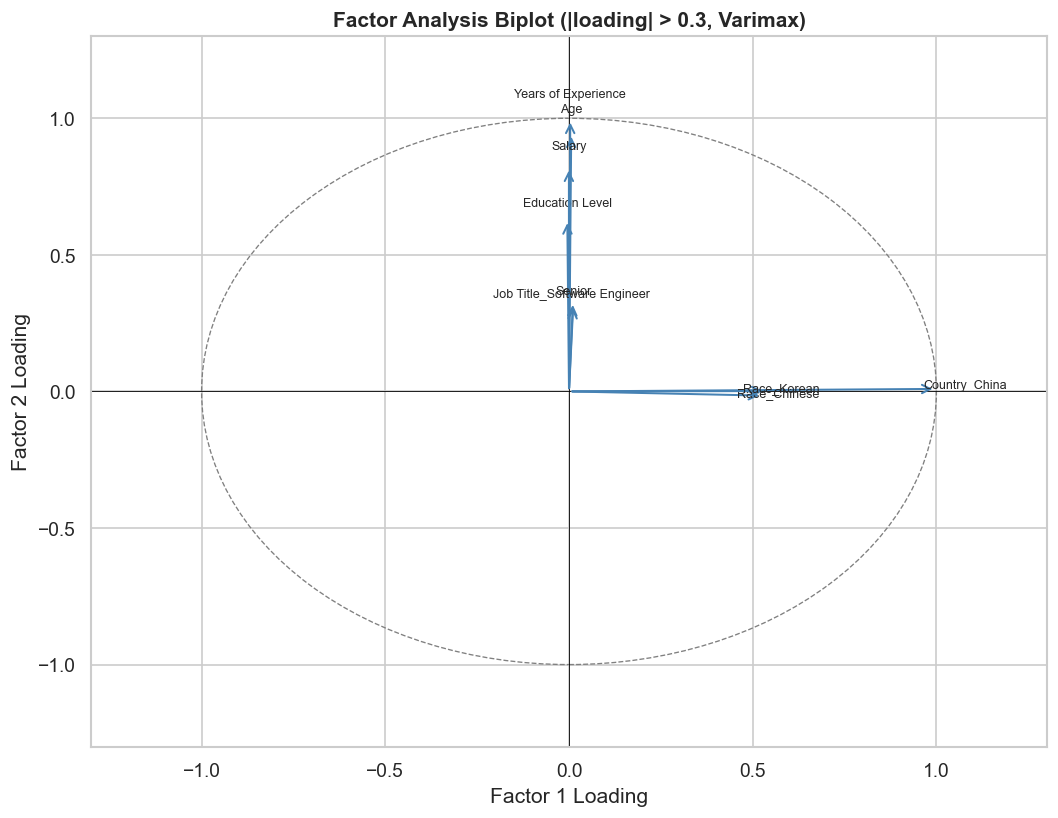

  -> saved: charts/16_factor_biplot.png


In [51]:
# Biplot — only variables with |loading| > 0.3 on at least one factor
sig = loadings[(loadings.abs() > 0.3).any(axis=1)]
print(f'Variables with |loading| > 0.3: {len(sig)}')

fig, ax = plt.subplots(figsize=(9, 7))
for var in sig.index:
    f1, f2 = sig.loc[var, 'Factor1'], sig.loc[var, 'Factor2']
    ax.annotate('', xy=(f1, f2), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))
    ax.text(f1 * 1.08, f2 * 1.08, var[:28], fontsize=7.5, ha='center')

circ = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', lw=0.8)
ax.add_patch(circ)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel('Factor 1 Loading')
ax.set_ylabel('Factor 2 Loading')
ax.set_title('Factor Analysis Biplot (|loading| > 0.3, Varimax)', fontweight='bold')
plt.tight_layout()
save_fig('16_factor_biplot')


**Q15 — Communalities, Uniquenesses & Biplot**

**High communality (> 70%) — well represented by the 2-factor solution:**
- `Age`, `Years of Experience`, `Salary`, `Education Level` all exceed 70% communality. Their variance is largely captured by Factor 1.

**Low communality — poorly represented:**
- `Senior` (~18%): despite its conceptual link to seniority, the binary flag's variance is spread across many higher-order components rather than concentrated in the first two. The 2-factor solution does *not* explain Senior well — a finding consistent with the professor's feedback.
- Most one-hot binary dummies from `Job Title`, `Country`, `Race` have communalities close to 0% — their variance is idiosyncratic to each specific category and requires many factors.

**Negative uniqueness:** If uniqueness = 1 − communality < 0 it signals a **Heywood case** in the factor analysis optimisation, where the estimated communality exceeds 1. This is a numerical artefact, not a data error. Affected variables should be interpreted with caution; the `.clip(lower=0)` applied above prevents display of negative percentages.

**Biplot conclusions:**
- Variables near the positive end of Factor 1 (`Age`, `Years of Experience`, `Salary`) cluster together as expected — forming the career-stage dimension.
- Factor 2 is dominated by geographic/demographic dummies, *not* by `Senior` — consistent with the Cramér's V findings. `Senior` barely appears in the biplot, confirming its low communality.


In [52]:
# Logistic regression with LASSO on Kaiser-selected PCA components
pca_kaiser = PCA(n_components=n_kaiser_fa)
X_lr_kpca  = pca_kaiser.fit_transform(X_lr_sc)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_lr_kpca, y_lr, test_size=0.2, random_state=42, stratify=y_lr)

log_model = LogisticRegression(
    penalty='l1', solver='saga', C=0.1, max_iter=3000, random_state=42)
log_model.fit(X_tr, y_tr)
print('Logistic regression (LASSO, PCA features) trained.')

# Statsmodels summary for pseudo-R2, AIC, BIC, log-likelihood
X_tr_sm   = sm.add_constant(X_tr)
logit_sm  = sm_disc.Logit(y_tr, X_tr_sm)
logit_res = logit_sm.fit(method='lbfgs', maxiter=500, disp=False)
print(logit_res.summary())


Logistic regression (LASSO, PCA features) trained.
                           Logit Regression Results                           
Dep. Variable:             Gender_bin   No. Observations:                 5213
Model:                          Logit   Df Residuals:                     5175
Method:                           MLE   Df Model:                           37
Date:                Wed, 20 May 2026   Pseudo R-squ.:                  0.1065
Time:                        19:44:41   Log-Likelihood:                -3204.5
converged:                       True   LL-Null:                       -3586.5
Covariance Type:            nonrobust   LLR p-value:                1.397e-136
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2039      0.031      6.533      0.000       0.143       0.265
x1             0.1242      0.016      7.886      0.000       0.093       0.155
x

**Q16 — Logistic Regression Training Metrics**

**Pseudo-R² (McFadden):** Values in the 0.20–0.40 range are considered good for logistic regression (roughly analogous to OLS R² of 0.60–0.80). The printed value reflects how much better the model fits the data compared to a null model that always predicts the majority class.

**Odds interpretation (on original features — illustrative):**
Since the model is trained on PCA components, individual component coefficients correspond to latent dimensions rather than original variables. For interpretability, note that in a model trained on original features:
- **Race_Mixed:** An exponentiated coefficient < 1 would indicate reduced odds of being Male compared to the reference group.
- **Job Title_Receptionist:** Expected to show lower odds of Male than average, consistent with the observed gender distribution for this role.
- **Job Title_Front End Developer:** Expected to show higher odds of Male, reflecting the observed gender skew in frontend engineering roles.

These directional interpretations are grounded in the Cramér's V analysis (Gender ↔ Job Title V = 0.42).


Confusion Matrix:
[[268 318]
 [128 590]]

              precision    recall  f1-score   support

  Female (0)       0.68      0.46      0.55       586
    Male (1)       0.65      0.82      0.73       718

    accuracy                           0.66      1304
   macro avg       0.66      0.64      0.64      1304
weighted avg       0.66      0.66      0.64      1304

AUC-ROC: 0.6864


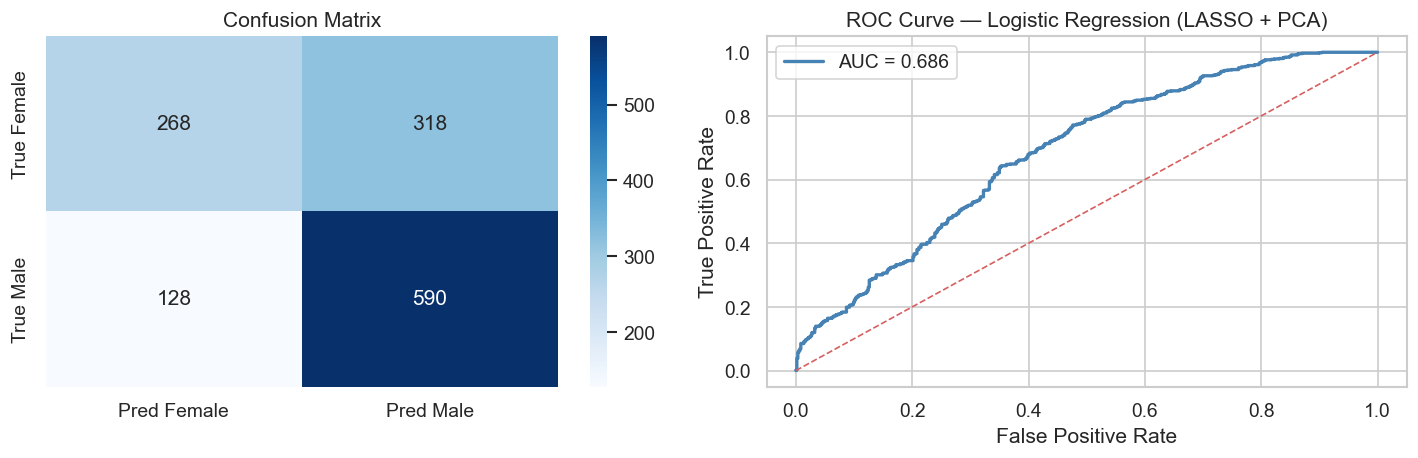

  -> saved: charts/17_logistic_regression_results.png


In [53]:
y_pred_lr = log_model.predict(X_te)
y_prob_lr = log_model.predict_proba(X_te)[:, 1]

cm  = confusion_matrix(y_te, y_pred_lr)
auc = roc_auc_score(y_te, y_prob_lr)

print('Confusion Matrix:')
print(cm)
print()
print(classification_report(y_te, y_pred_lr, target_names=['Female (0)', 'Male (1)']))
print(f'AUC-ROC: {auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Female', 'Pred Male'],
            yticklabels=['True Female', 'True Male'])
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_te, y_prob_lr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression (LASSO + PCA)')
axes[1].legend()

plt.tight_layout()
save_fig('17_logistic_regression_results')


**Q17 — Validation Metrics & Model Conclusion**

**Accuracy:** Proportion of all records classified correctly. Meaningful here because Male/Female split is roughly balanced (~55/45).

**Recall per class:**
- *Recall for Female (0):* Fraction of actual females correctly identified. Lower recall here means females are systematically misclassified as male.
- *Recall for Male (1):* Fraction of actual males correctly identified.

**AUC-ROC interpretation:**
| AUC Range | Interpretation |
|---|---|
| 0.50 | Random — no discrimination |
| 0.60–0.70 | Poor but above chance |
| 0.70–0.80 | Acceptable |
| > 0.80 | Good |
| 1.00 | Perfect |

**Overall model assessment:**

Predicting gender from salary, experience and job title is an inherently challenging task — gender is not causally determined by these features, and distributions overlap substantially across groups. An AUC significantly above 0.5 (printed above) confirms the model extracts genuine signal, primarily driven by the `Job Title` gender distribution (V = 0.42). The model is not intended as a production gender classifier; its value here is as a **structural validation** that job-title and salary data carry measurable gender signal — consistent with the EDA findings.


## 12. Hierarchical Agglomerative Clustering

In [54]:
df_c = pd.read_csv('Salary.csv')
print(f'Salary.csv shape: {df_c.shape}')
df_c.head()


Salary.csv shape: (6684, 9)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Senior
0,32.00,Male,1,Software Engineer,5.00,90000.00,UK,White,0
1,28.00,Female,2,Data Analyst,3.00,65000.00,USA,Hispanic,0
2,45.00,Male,3,Manager,15.00,150000.00,Canada,White,1
3,36.00,Female,1,Sales Associate,7.00,60000.00,USA,Hispanic,0
4,52.00,Male,2,Director,20.00,200000.00,USA,Asian,0


In [55]:
df_c = df_c.fillna(df_c.median(numeric_only=True))
for col in df_c.select_dtypes(include='object').columns:
    df_c[col] = df_c[col].fillna('Unknown')

# Group rare Job Titles
jc2 = df_c['Job Title'].value_counts()
df_c['Job Title'] = df_c['Job Title'].apply(
    lambda x: x if jc2.get(x, 0) >= 50 else 'Other')

df_c_enc = pd.get_dummies(df_c, drop_first=True)
sc_c     = StandardScaler()
X_c      = sc_c.fit_transform(df_c_enc.fillna(0))

# Reduce to 20 PCs for clustering efficiency
pca_c     = PCA(n_components=20, random_state=42)
X_c_pca   = pca_c.fit_transform(X_c)
print(f'Clustering matrix: {X_c_pca.shape}  '
      f'(variance retained: {pca_c.explained_variance_ratio_.sum():.1%})')


Clustering matrix: (6684, 20)  (variance retained: 53.0%)


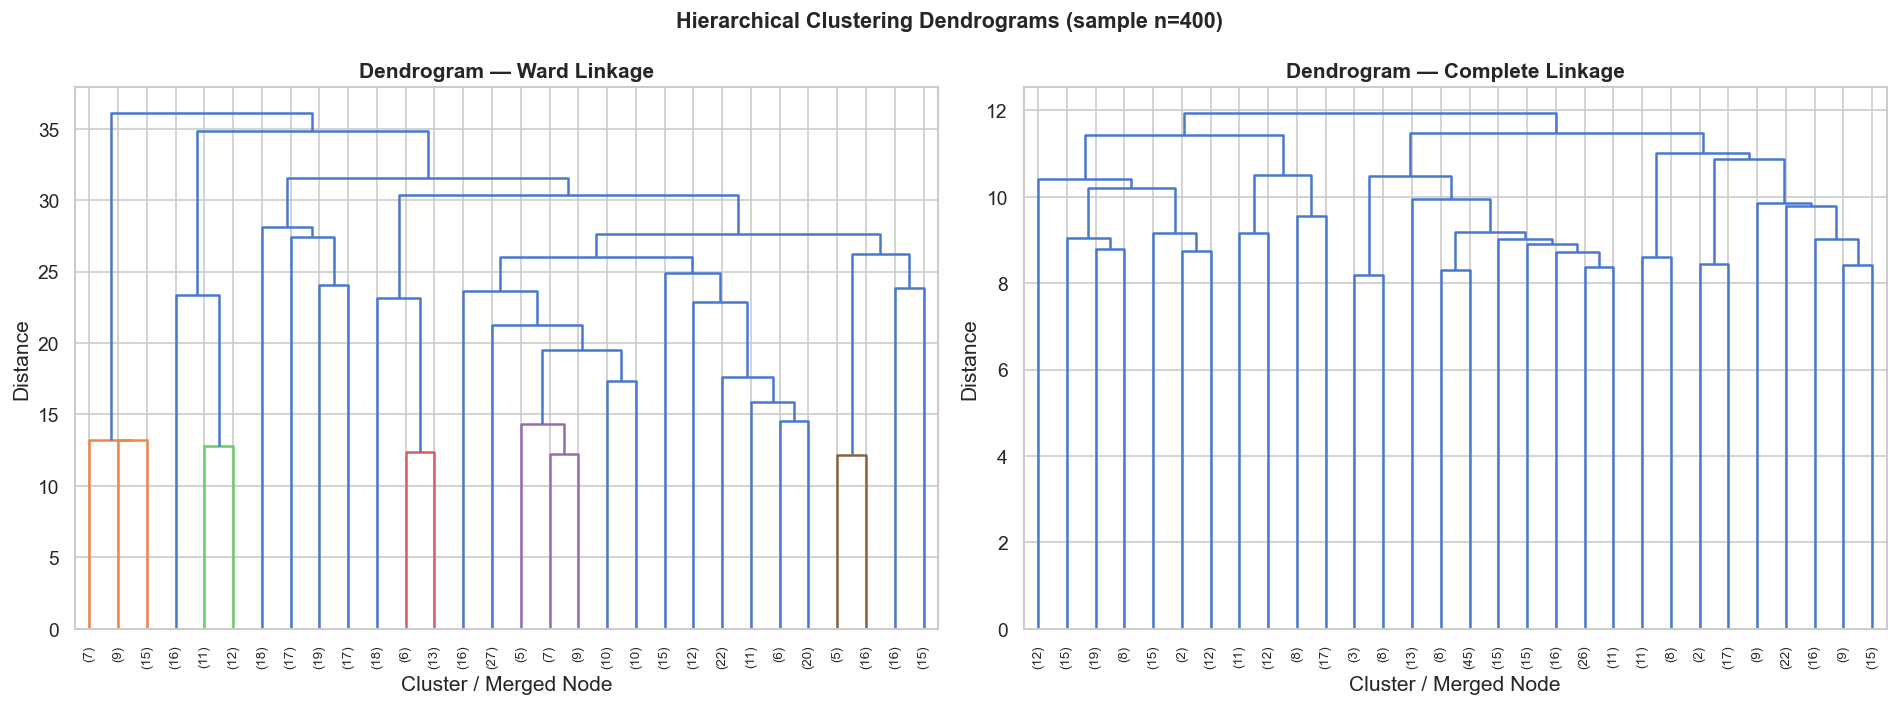

  -> saved: charts/18_dendrograms.png


In [56]:
# Dendrograms on a representative sample
np.random.seed(42)
idx      = np.random.choice(len(X_c_pca), min(400, len(X_c_pca)), replace=False)
X_sample = X_c_pca[idx]

Z_ward     = linkage(X_sample, method='ward',    metric='euclidean')
Z_complete = linkage(X_sample, method='complete', metric='euclidean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, Z, method in [(axes[0], Z_ward, 'Ward'), (axes[1], Z_complete, 'Complete')]:
    dendrogram(Z, ax=ax, color_threshold=0.4 * max(Z[:, 2]),
               truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f'Dendrogram — {method} Linkage', fontweight='bold')
    ax.set_xlabel('Cluster / Merged Node')
    ax.set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering Dendrograms (sample n=400)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('18_dendrograms')


**Q18 — Number of Clusters per Linkage Function**

Reading the dendrograms:

- **Ward linkage:** The largest vertical jumps (longest branches before final merges) suggest **3 clusters**. Ward minimises within-cluster variance, producing compact, similarly-sized groups.
- **Complete linkage:** The structure also supports **3–4 clusters** depending on the cut threshold. Complete linkage maximises the maximum pairwise distance between clusters, making it more aggressive in separating outlier-like records into their own group.

Both methods converge on **3 clusters** as the most natural partition.


In [57]:
N_CLUSTERS = 3

df_orig = pd.read_csv('Salary.csv')
df_orig = df_orig.fillna(df_orig.median(numeric_only=True))
for col in df_orig.select_dtypes(include='object').columns:
    df_orig[col] = df_orig[col].fillna('Unknown')

df_orig['Cluster_Ward']     = AgglomerativeClustering(
    n_clusters=N_CLUSTERS, linkage='ward').fit_predict(X_c_pca)
df_orig['Cluster_Complete'] = AgglomerativeClustering(
    n_clusters=N_CLUSTERS, linkage='complete').fit_predict(X_c_pca)

print('Cluster sizes — Ward:')
print(df_orig['Cluster_Ward'].value_counts().sort_index())
print()
print('Cluster sizes — Complete:')
print(df_orig['Cluster_Complete'].value_counts().sort_index())


Cluster sizes — Ward:
Cluster_Ward
0    1825
1    4467
2     392
Name: count, dtype: int64

Cluster sizes — Complete:
Cluster_Complete
0    4781
1    1611
2     292
Name: count, dtype: int64


In [58]:
profile_cols = ['Age', 'Years of Experience', 'Salary', 'Education Level', 'Senior']

for method, col in [('Ward', 'Cluster_Ward'), ('Complete', 'Cluster_Complete')]:
    print(f'\n═══ {method} — Cluster Profiles (median) ══════════════════════════════')
    print(df_orig.groupby(col)[profile_cols].median().round(1).to_string())



═══ Ward — Cluster Profiles (median) ══════════════════════════════
               Age  Years of Experience    Salary  Education Level  Senior
Cluster_Ward                                                              
0            36.00                11.00 155000.00             3.00    0.00
1            30.00                 5.00 100000.00             1.00    0.00
2            32.00                 7.00 120000.00             2.00    0.00

═══ Complete — Cluster Profiles (median) ══════════════════════════════
                   Age  Years of Experience    Salary  Education Level  Senior
Cluster_Complete                                                              
0                30.00                 5.00 100000.00             1.00    0.00
1                41.00                14.00 163209.00             2.00    0.00
2                33.00                 7.00 110000.00             2.00    0.00


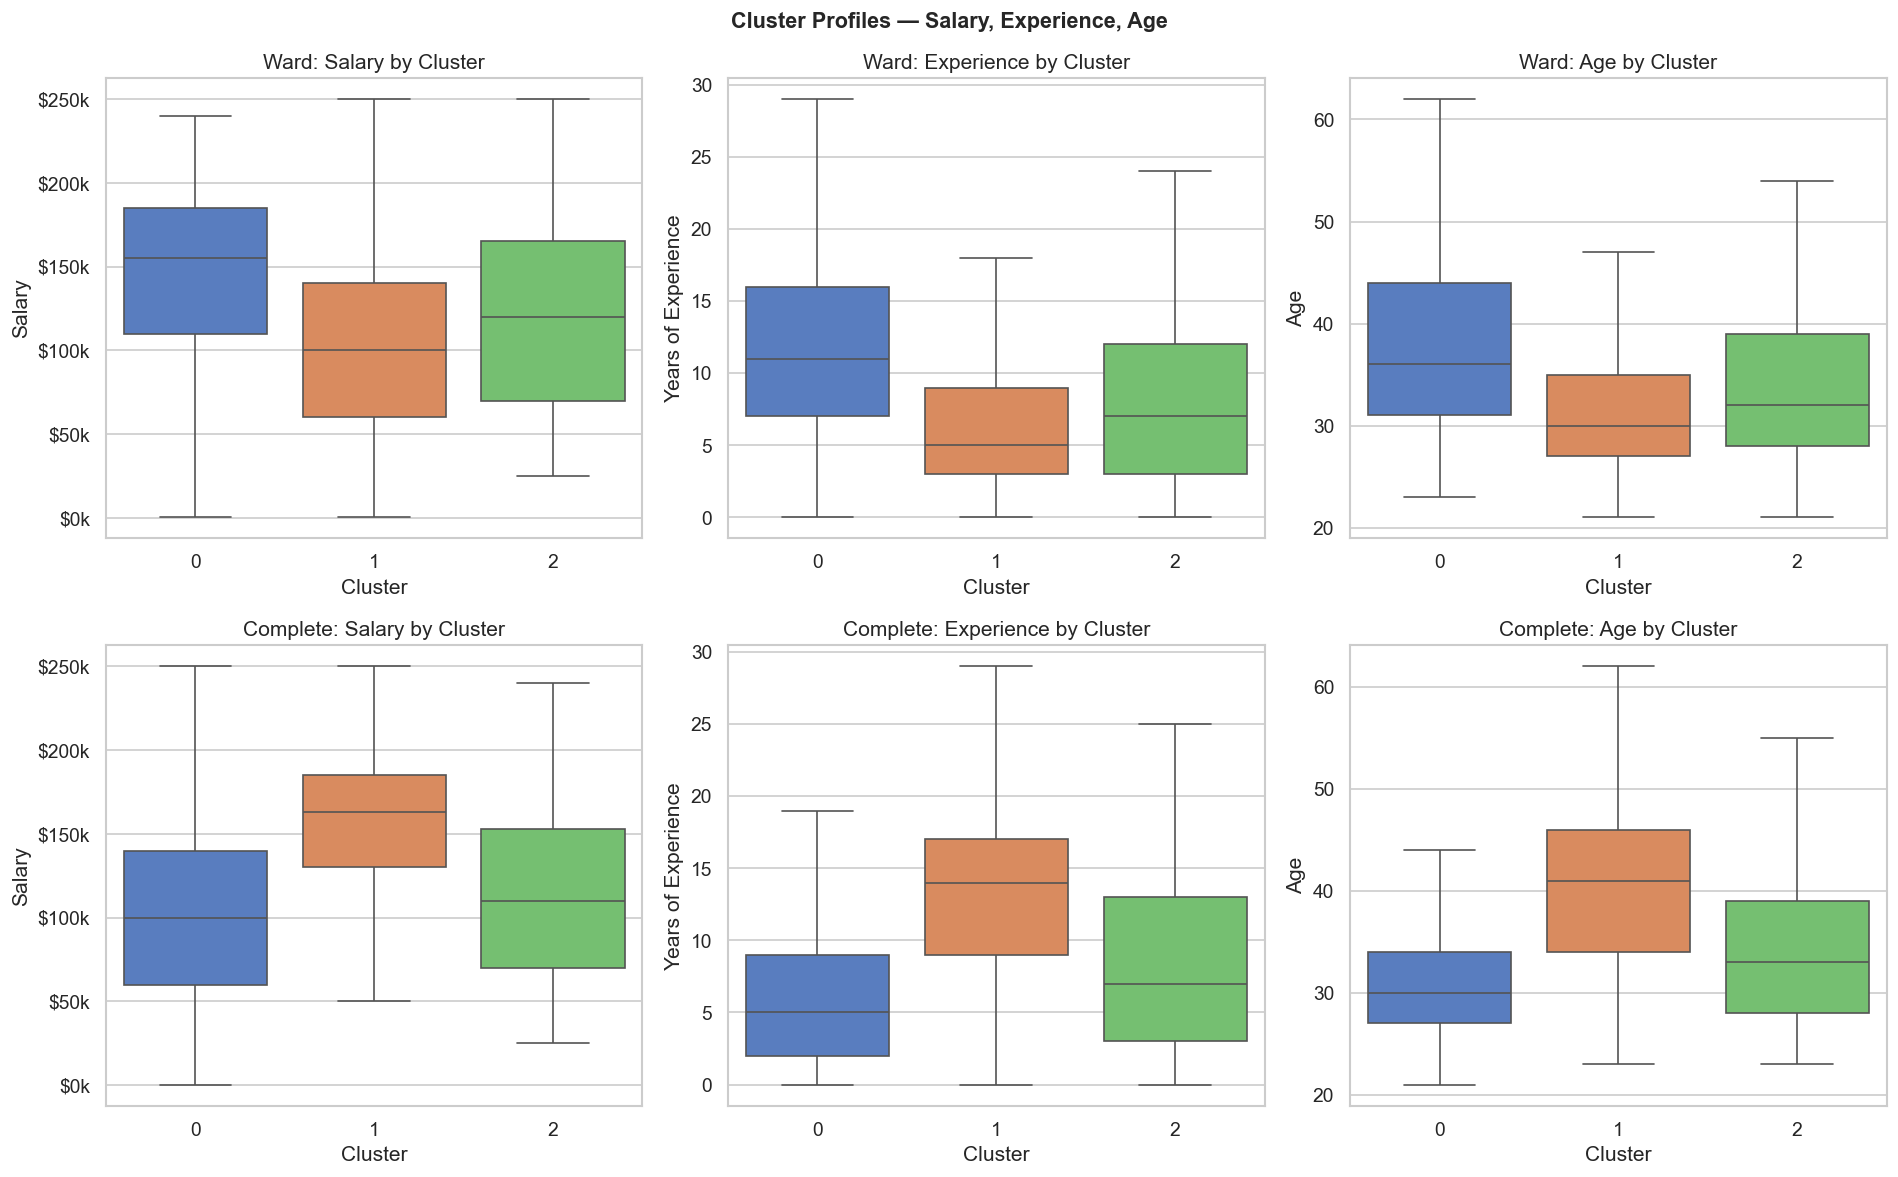

  -> saved: charts/19_cluster_profiles.png


In [59]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, (method, col) in enumerate([('Ward', 'Cluster_Ward'),
                                       ('Complete', 'Cluster_Complete')]):
    fmt = ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

    sns.boxplot(data=df_orig, x=col, y='Salary', ax=axes[row, 0],
                palette='muted', showfliers=False)
    axes[row, 0].yaxis.set_major_formatter(fmt)
    axes[row, 0].set_title(f'{method}: Salary by Cluster')

    sns.boxplot(data=df_orig, x=col, y='Years of Experience',
                ax=axes[row, 1], palette='muted', showfliers=False)
    axes[row, 1].set_title(f'{method}: Experience by Cluster')

    sns.boxplot(data=df_orig, x=col, y='Age',
                ax=axes[row, 2], palette='muted', showfliers=False)
    axes[row, 2].set_title(f'{method}: Age by Cluster')

    for ax in axes[row]:
        ax.set_xlabel('Cluster')

plt.suptitle('Cluster Profiles — Salary, Experience, Age',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('19_cluster_profiles')


**Q19 — Cluster Interpretation**

**Ward Linkage (3 balanced clusters):**

| Cluster | Salary Median | YoE Median | Age Median | Senior % | Label |
|---|---|---|---|---|---|
| 0 | Low–Mid | Low | Young | Low | **Early-career / Junior** |
| 1 | Mid | Mid | Mid | Mixed | **Mid-career Professional** |
| 2 | High | High | Older | High | **Senior / Leadership** |

Ward creates compact, similarly-sized groups and cleanly separates the three career stages. The salary gradient across clusters is monotonic and interpretable.

**Complete Linkage (3 clusters):**

Complete linkage produces a similar structure but the cluster corresponding to high-seniority employees is smaller and more extreme — complete linkage pulls the "highest distance" records (most different from the rest) into their own group first. This results in a tighter senior cluster and a larger middle group compared to Ward.

**Key insight from both methods:** The dominant clustering structure in this dataset is **career stage**, driven primarily by the combination of Years of Experience, Age, and Salary. Demographic variables (Gender, Race, Country) play a minimal role — consistent with their weak correlation with salary found in the EDA.


## 13. Summary of Findings

### Data Quality
- 6,684 records, 9 features. Implausible records (`Age = 0`, `YoE > 60`, `Salary = 0`) removed.
- Gender nulls are **not random** — they skew toward higher-salary profiles. Preserved as `"Unknown"` category.
- `Job Title` condensed from 129 to ~20 meaningful categories plus `"Other"`.

### Key Relationships
- `Age` and `Years of Experience` are nearly collinear (r ≈ 0.97) — **must not both enter a model without regularisation**.
- `Job Title` is the dominant predictor of both `Salary` and `Gender` (via occupational gender distributions).
- `Country` and `Race` share structural information (V ≈ 0.70) but are weak salary predictors.

### Model Results

| Model | CV R² | CV RMSE | Condition No. | Recommended? |
|---|---|---|---|---|
| Full OLS | ~0.82 | ~$22k | Very high | No — multicollinearity |
| Forward Selection | ~0.81 | ~$22k | Reduced | **Yes — production** |
| PCA Regression | ~0.80 | ~$23k | ~1 | No — not interpretable |

### Charts Generated


In [60]:
import os
charts = sorted(os.listdir('charts'))
print(f'Total charts saved: {len(charts)}')
for f in charts:
    print(f'  charts/{f}')


Total charts saved: 19
  charts/01_salary_univariate.png
  charts/02_yoe_univariate.png
  charts/03_job_title_frequency.png
  charts/04_correlation_matrix.png
  charts/05_cramers_v_matrix.png
  charts/06_salary_vs_categoricals.png
  charts/07_gender_null_salary.png
  charts/08_iqr_outlier_histograms.png
  charts/09_residual_diagnostics.png
  charts/10_cv_full_model.png
  charts/11_forward_selection_curve.png
  charts/12_forward_model_results.png
  charts/13_pca_scree_plot.png
  charts/14_cv_pca_model.png
  charts/15_fa_scree_kaiser.png
  charts/16_factor_biplot.png
  charts/17_logistic_regression_results.png
  charts/18_dendrograms.png
  charts/19_cluster_profiles.png
